In [1]:
import cellcharter as cc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns
import scanpy as sc
import anndata as ad
import os
import json
from scipy.stats import kruskal, mannwhitneyu
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp
import warnings
warnings.filterwarnings("ignore")

/Users/lukashat/miniforge3/envs/cellcharter_scarches/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [24]:
extension = 'png'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [3]:
celltype = 'PCs'
adata.obs['disease2'] = adata.obs['disease2'].astype(str)
adata = adata[adata.obs['disease2'].isin(['MM_BD', 'MM_noBD'])]
adata.obs['disease2'] = adata.obs['disease2'].astype('category')
disease_mapping = adata.obs[['disease2', 'image_ID']].drop_duplicates()
disease_mapping.set_index('image_ID', inplace=True)

In [4]:
df = adata[
    (adata.obs['Phenotype4'] == celltype)].to_df()
df['distance_to_bone_corrected'] = adata.obs.loc[df.index, 'distance_to_bone_corrected']
df['disease2'] = adata.obs.loc[df.index, 'disease2']
df['image_ID'] = adata.obs.loc[df.index, 'image_ID']
df['patient_ID'] = adata.obs.loc[df.index, 'patient_ID']
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], 
                           bins=range(0, 1001, 250))
df = df.dropna(subset=['distance_bin'])
df['distance_bin'] = df['distance_bin'].astype(str)

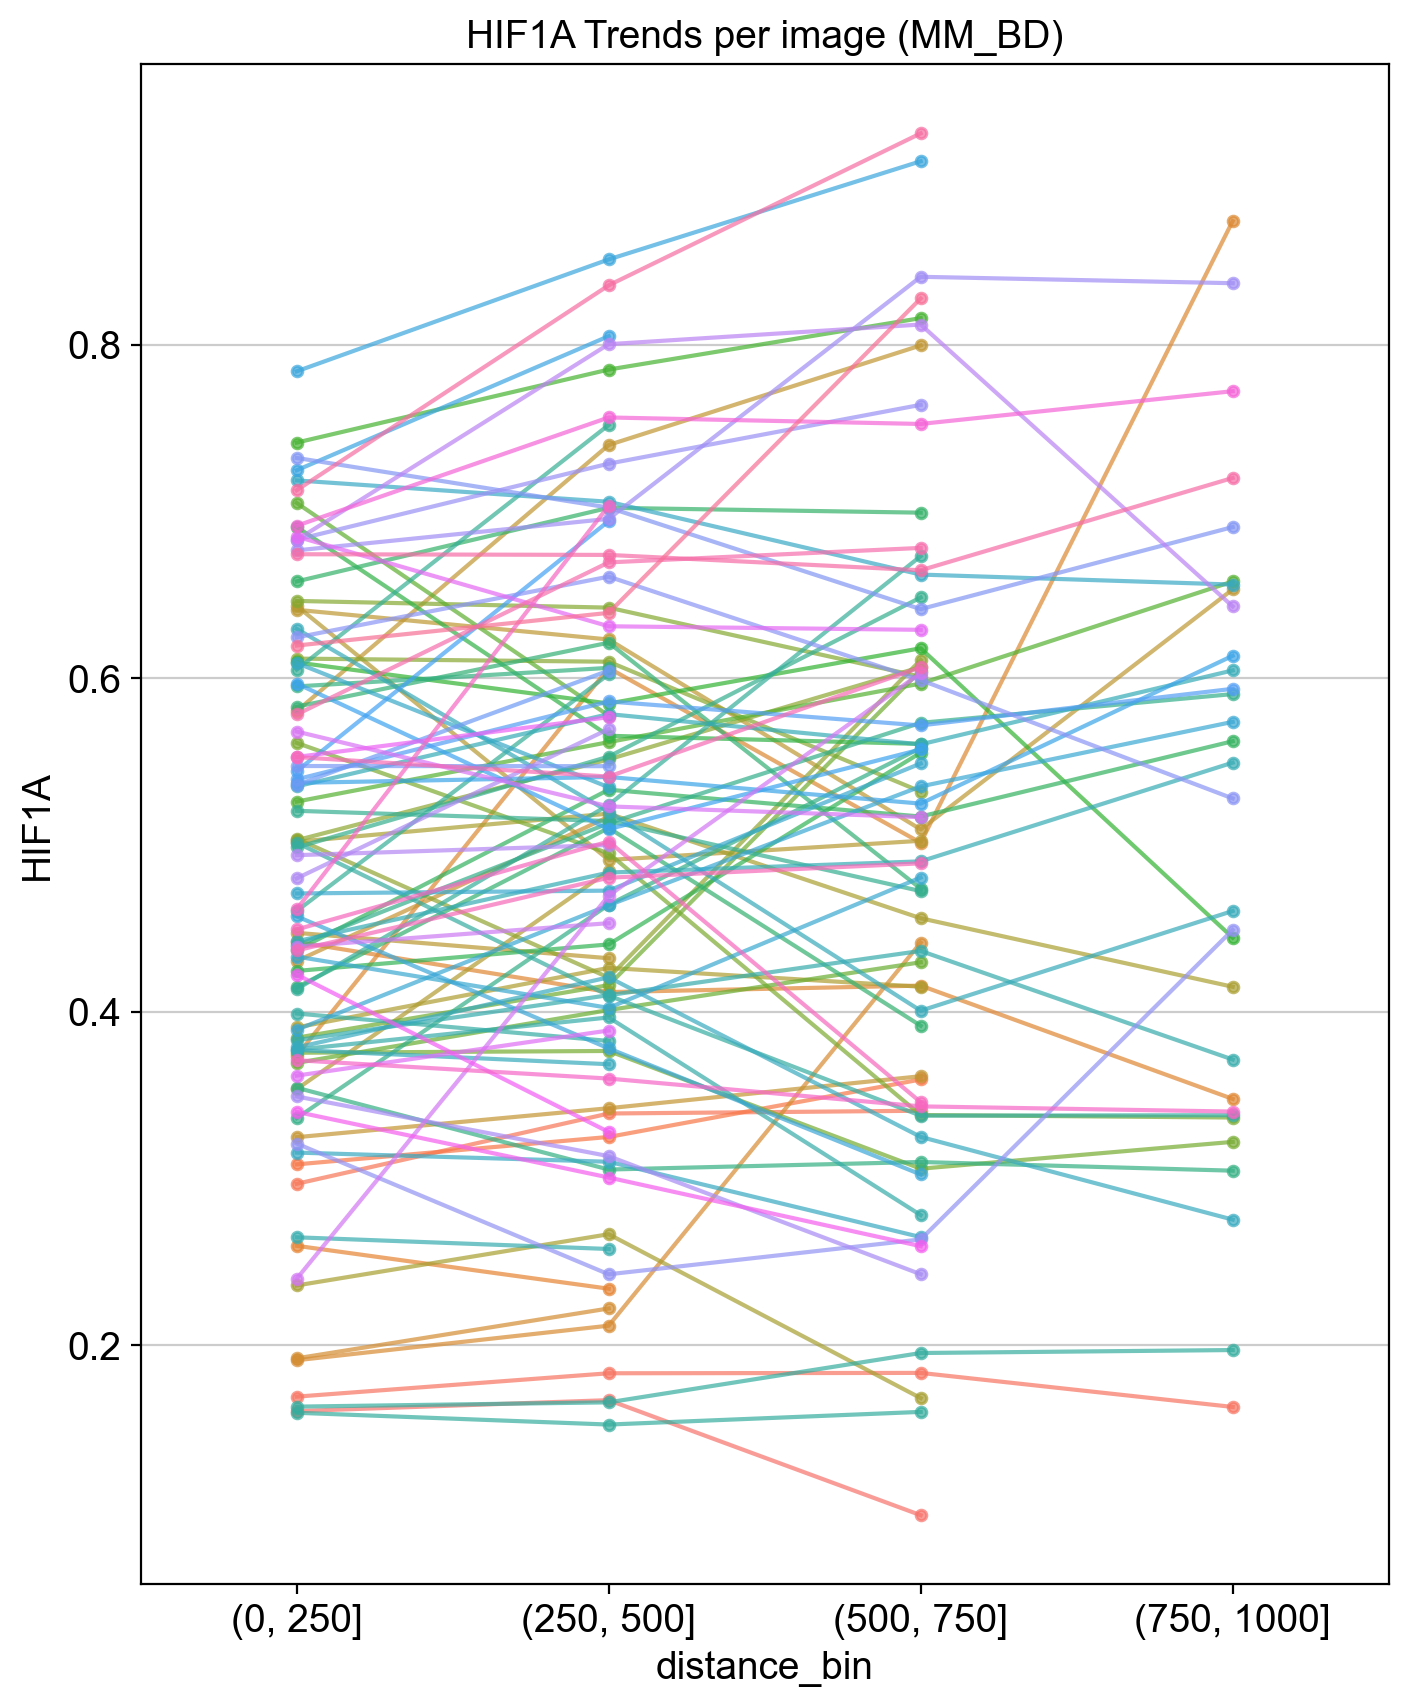

In [27]:
plt.figure(figsize=(8,10))
marker = 'HIF1A'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_BD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID', # Color lines by patient
    errorbar=None,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_BD)")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_MM_BD.{extension}'))

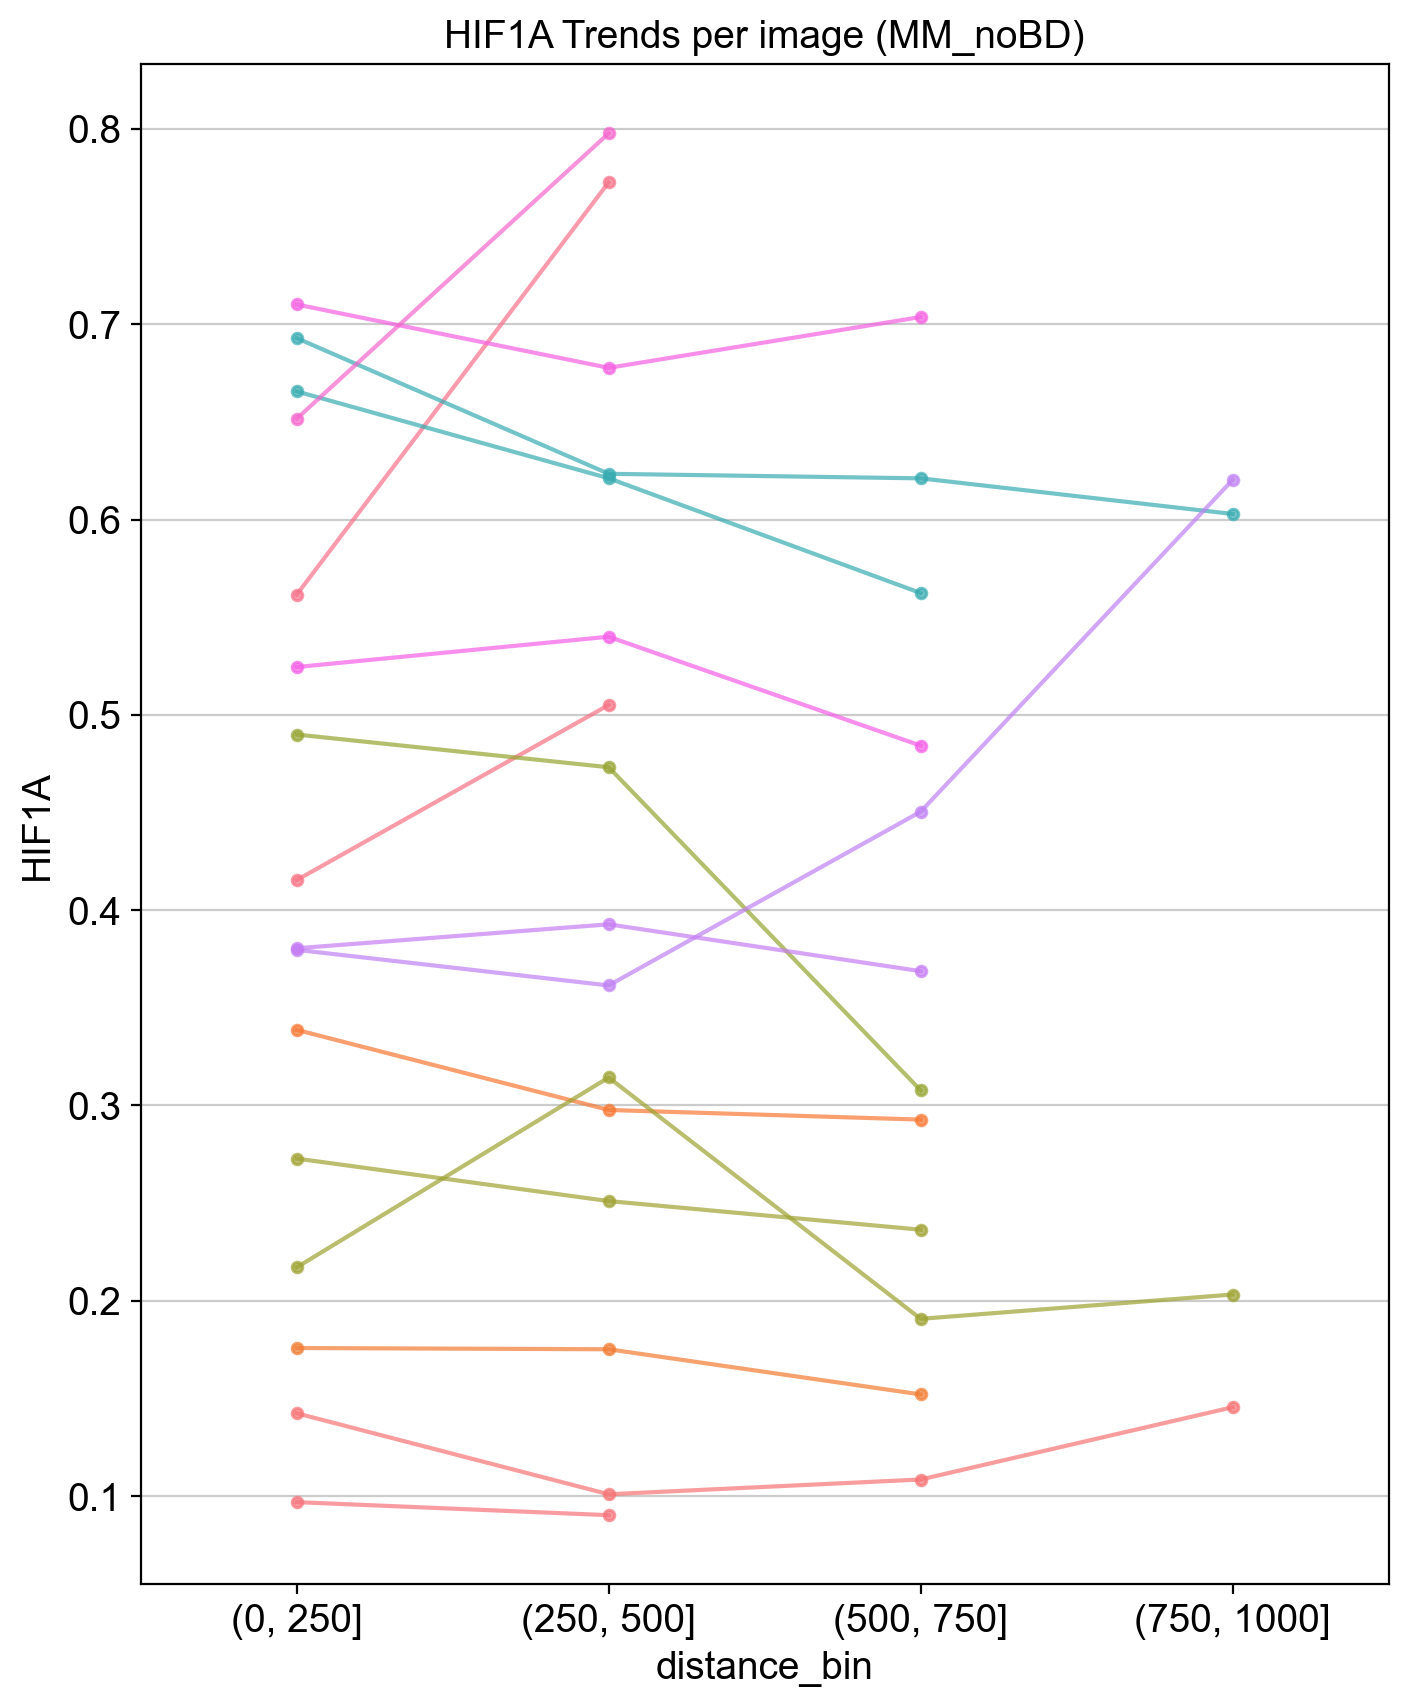

In [28]:
plt.figure(figsize=(8,10))
marker = 'HIF1A'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_noBD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID', # Color lines by patient
    errorbar=None,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_noBD)")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_MM_noBD.{extension}'))

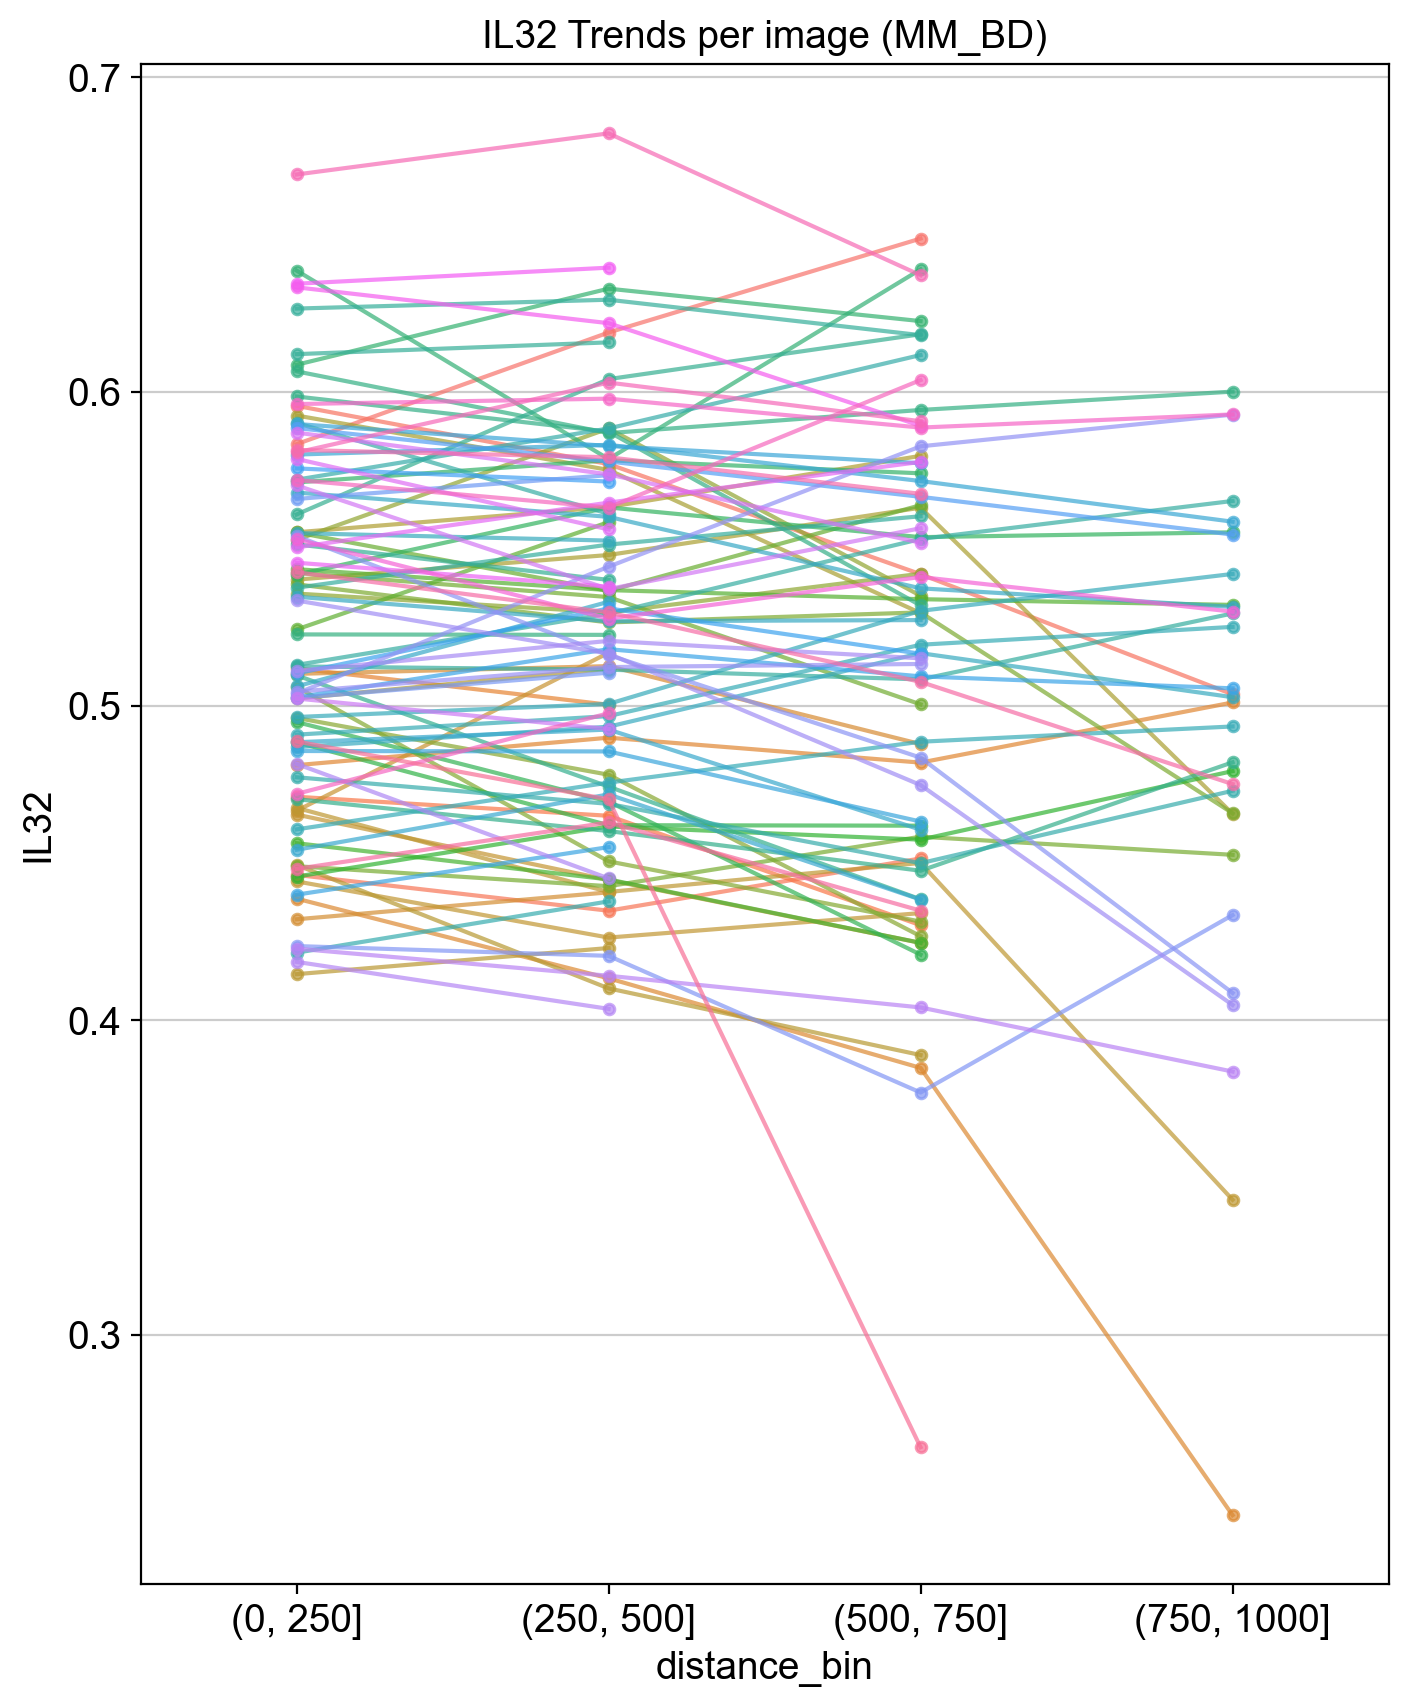

In [29]:
plt.figure(figsize=(8,10))
marker = 'IL32'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_BD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_BD)")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_MM_BD.{extension}'))

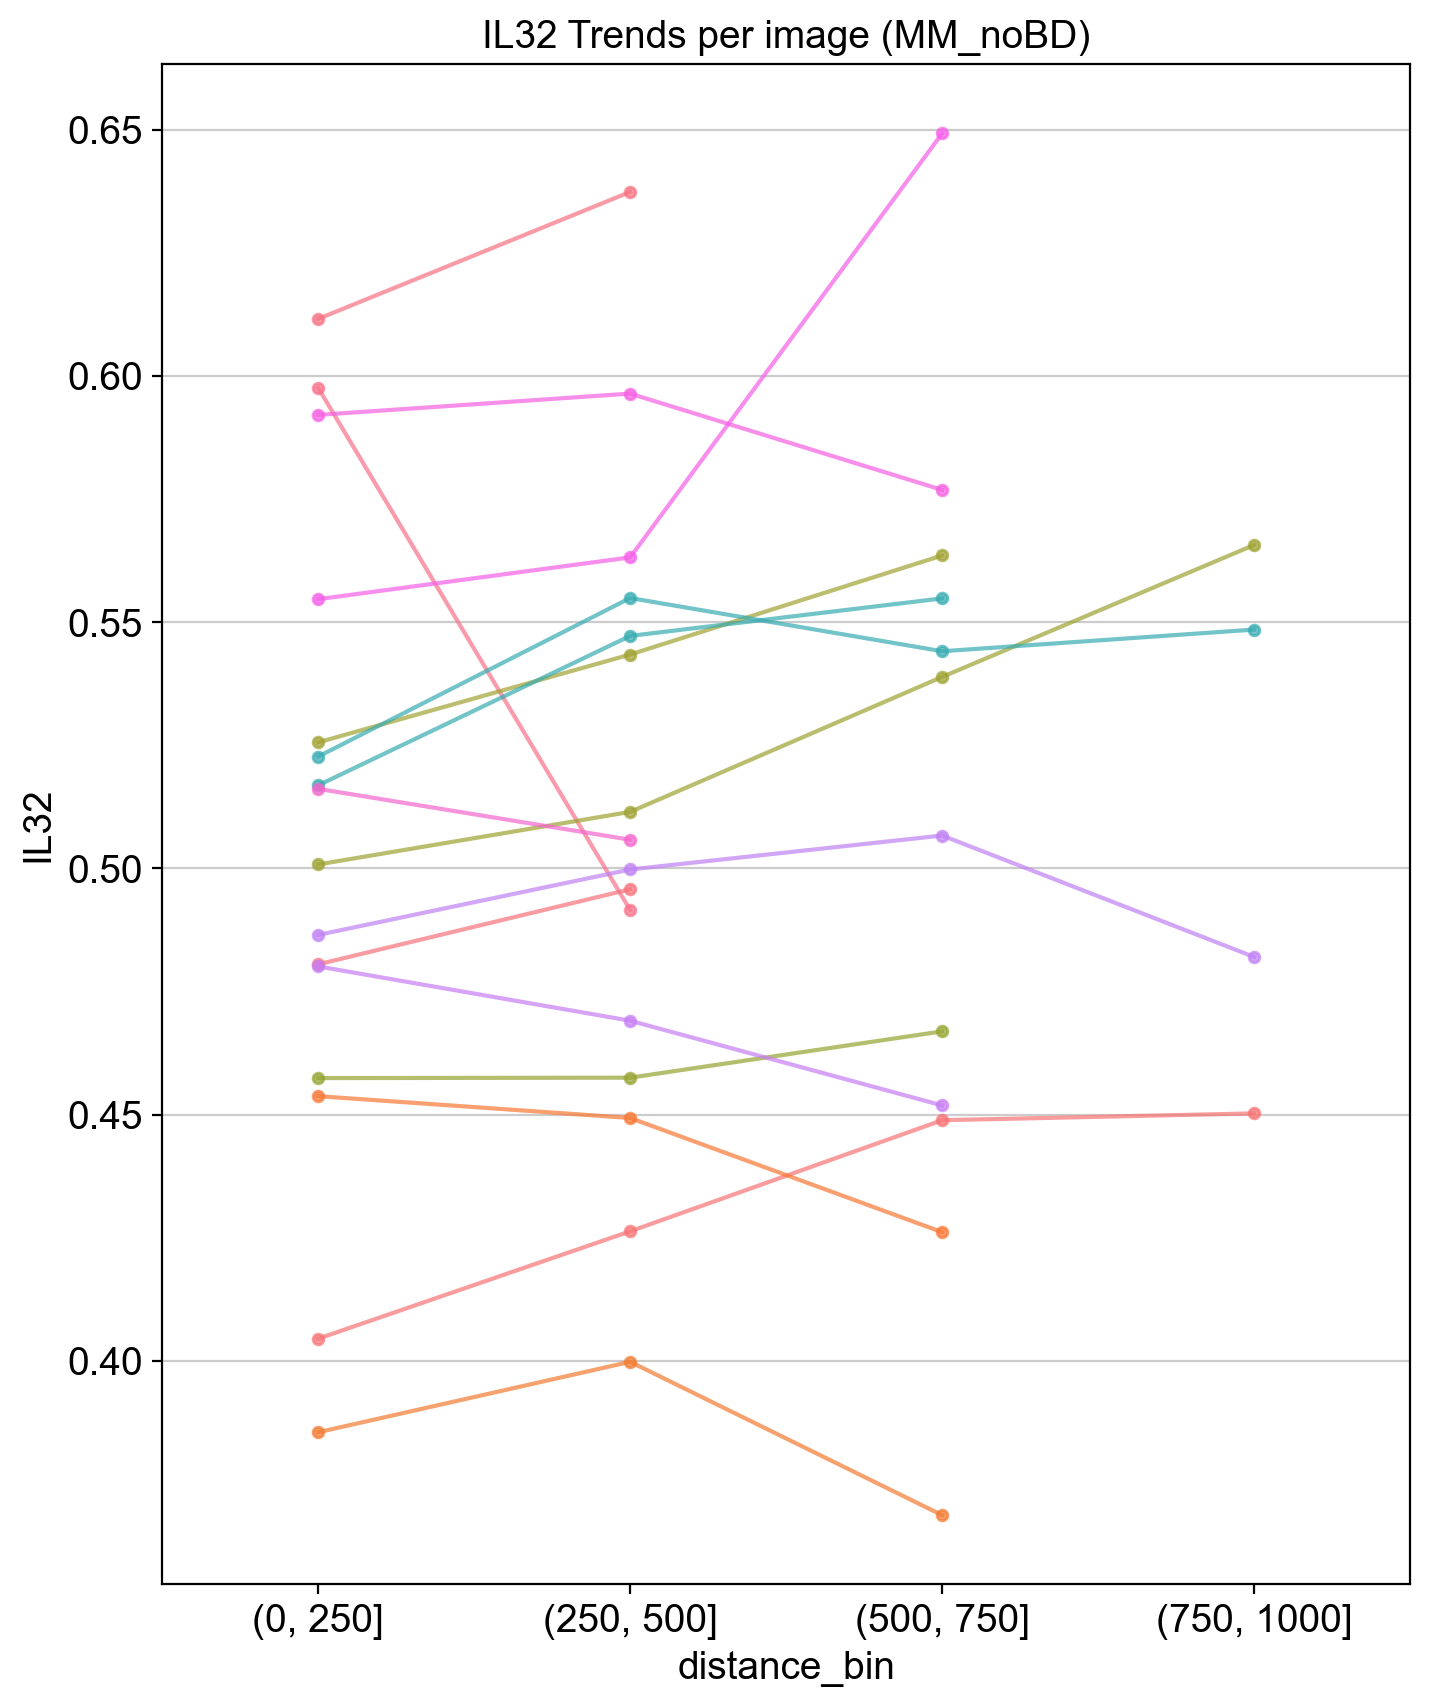

In [30]:
plt.figure(figsize=(8,10))
marker = 'IL32'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_noBD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID', # Color lines by patient
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_noBD)")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_MM_noBD.{extension}'))

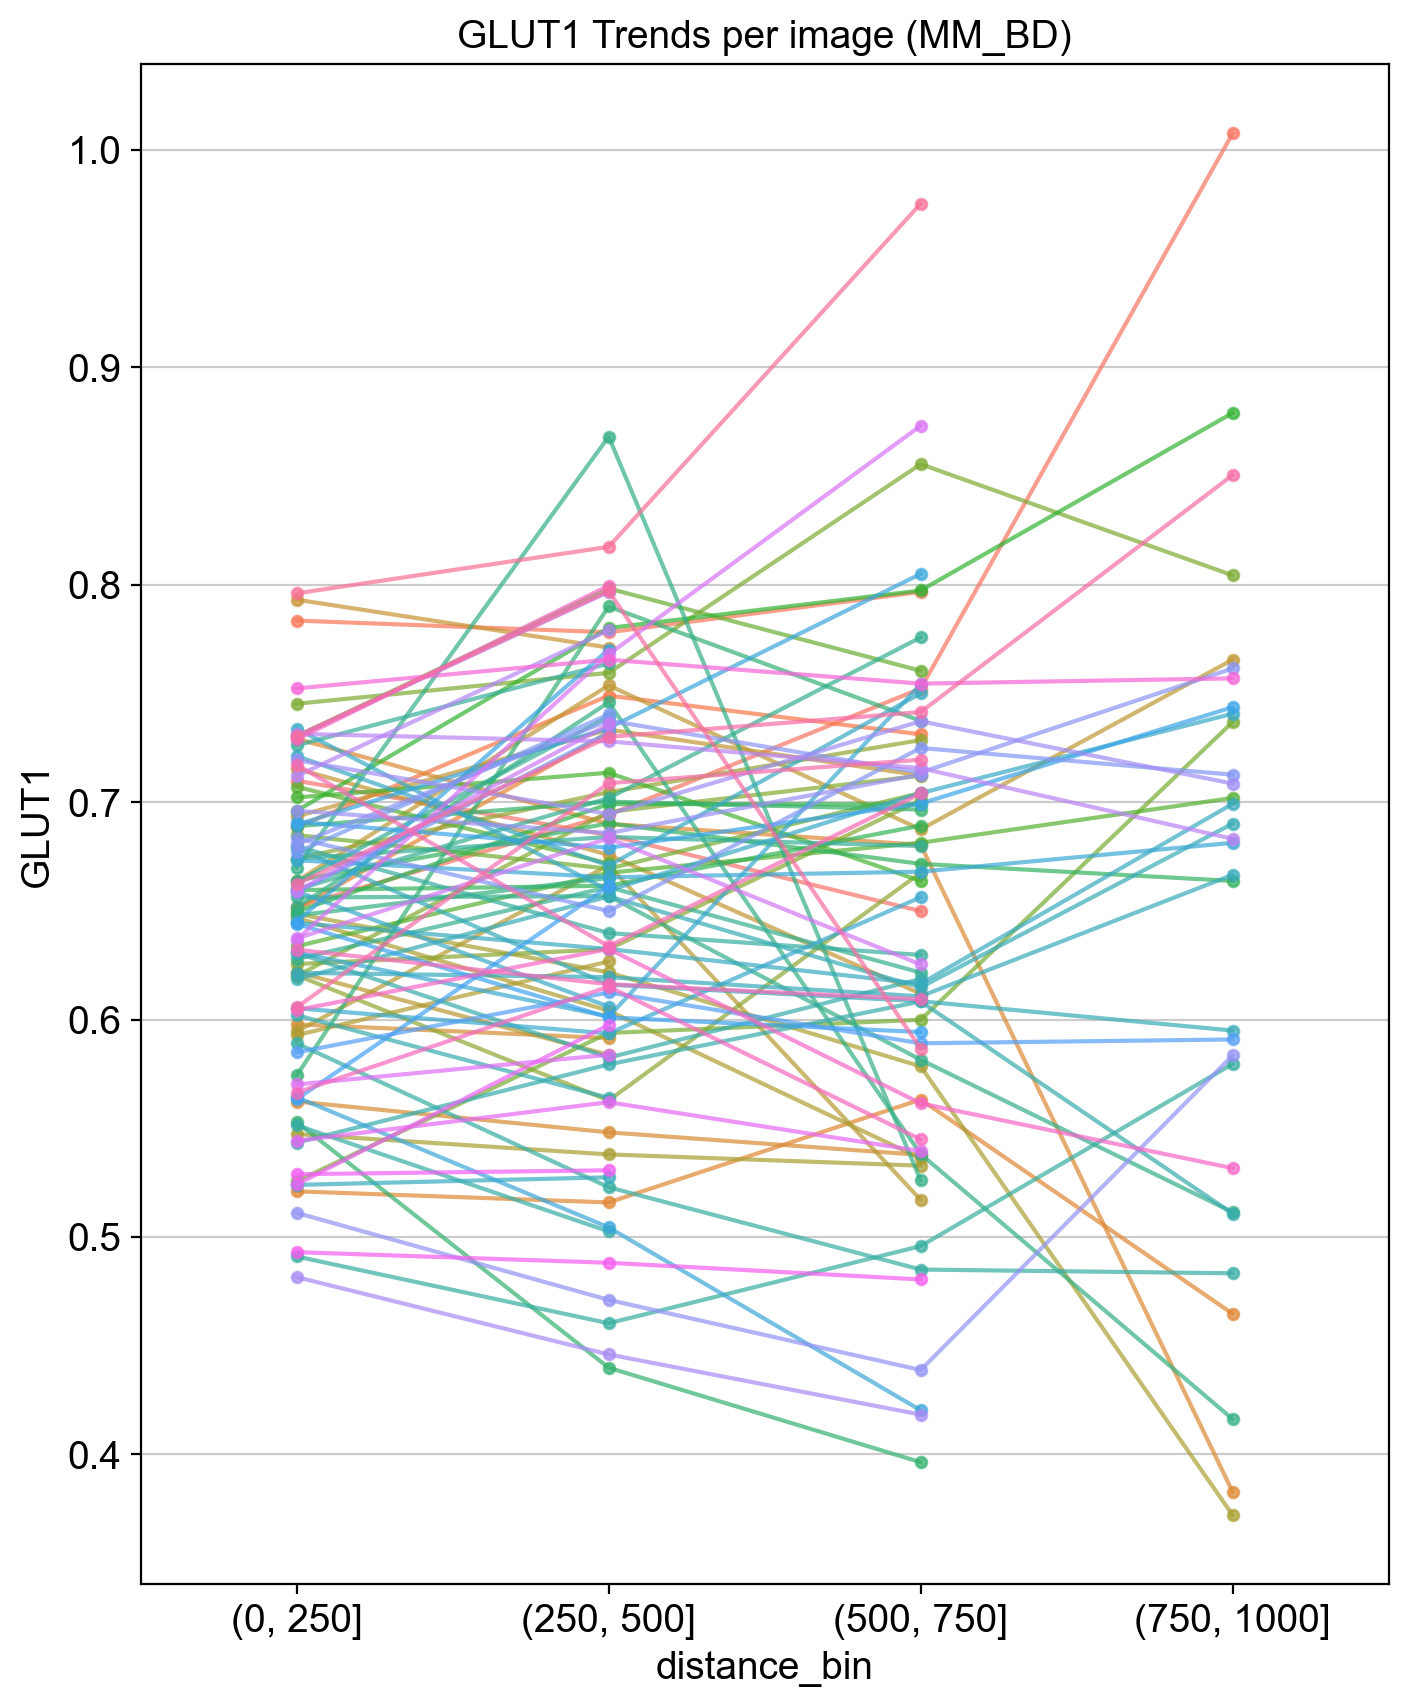

In [22]:
plt.figure(figsize=(8,10))
marker = 'GLUT1'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_BD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_BD)")
plt.show()

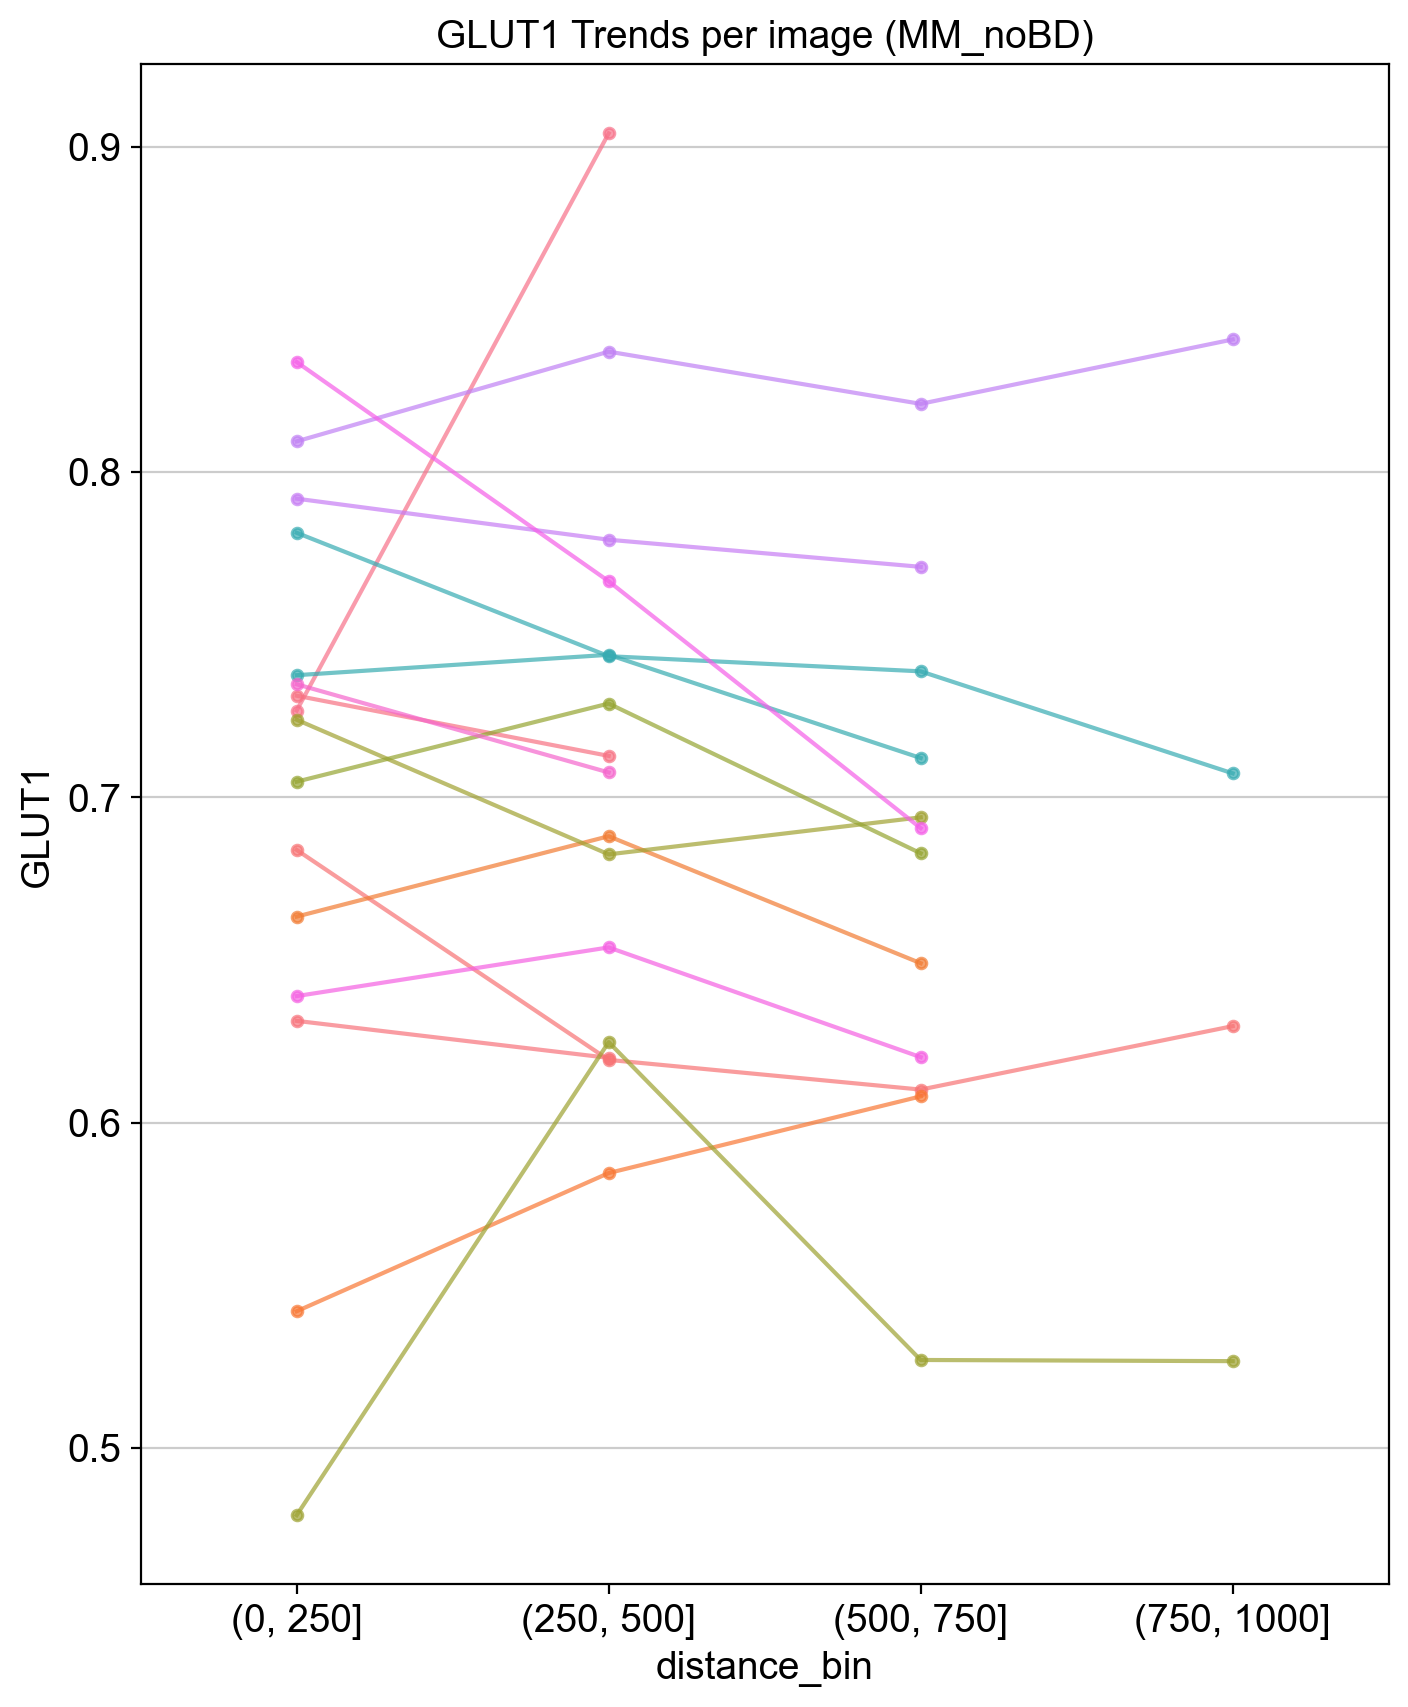

In [23]:
plt.figure(figsize=(8,10))
marker = 'GLUT1'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_noBD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_noBD)")
plt.show()

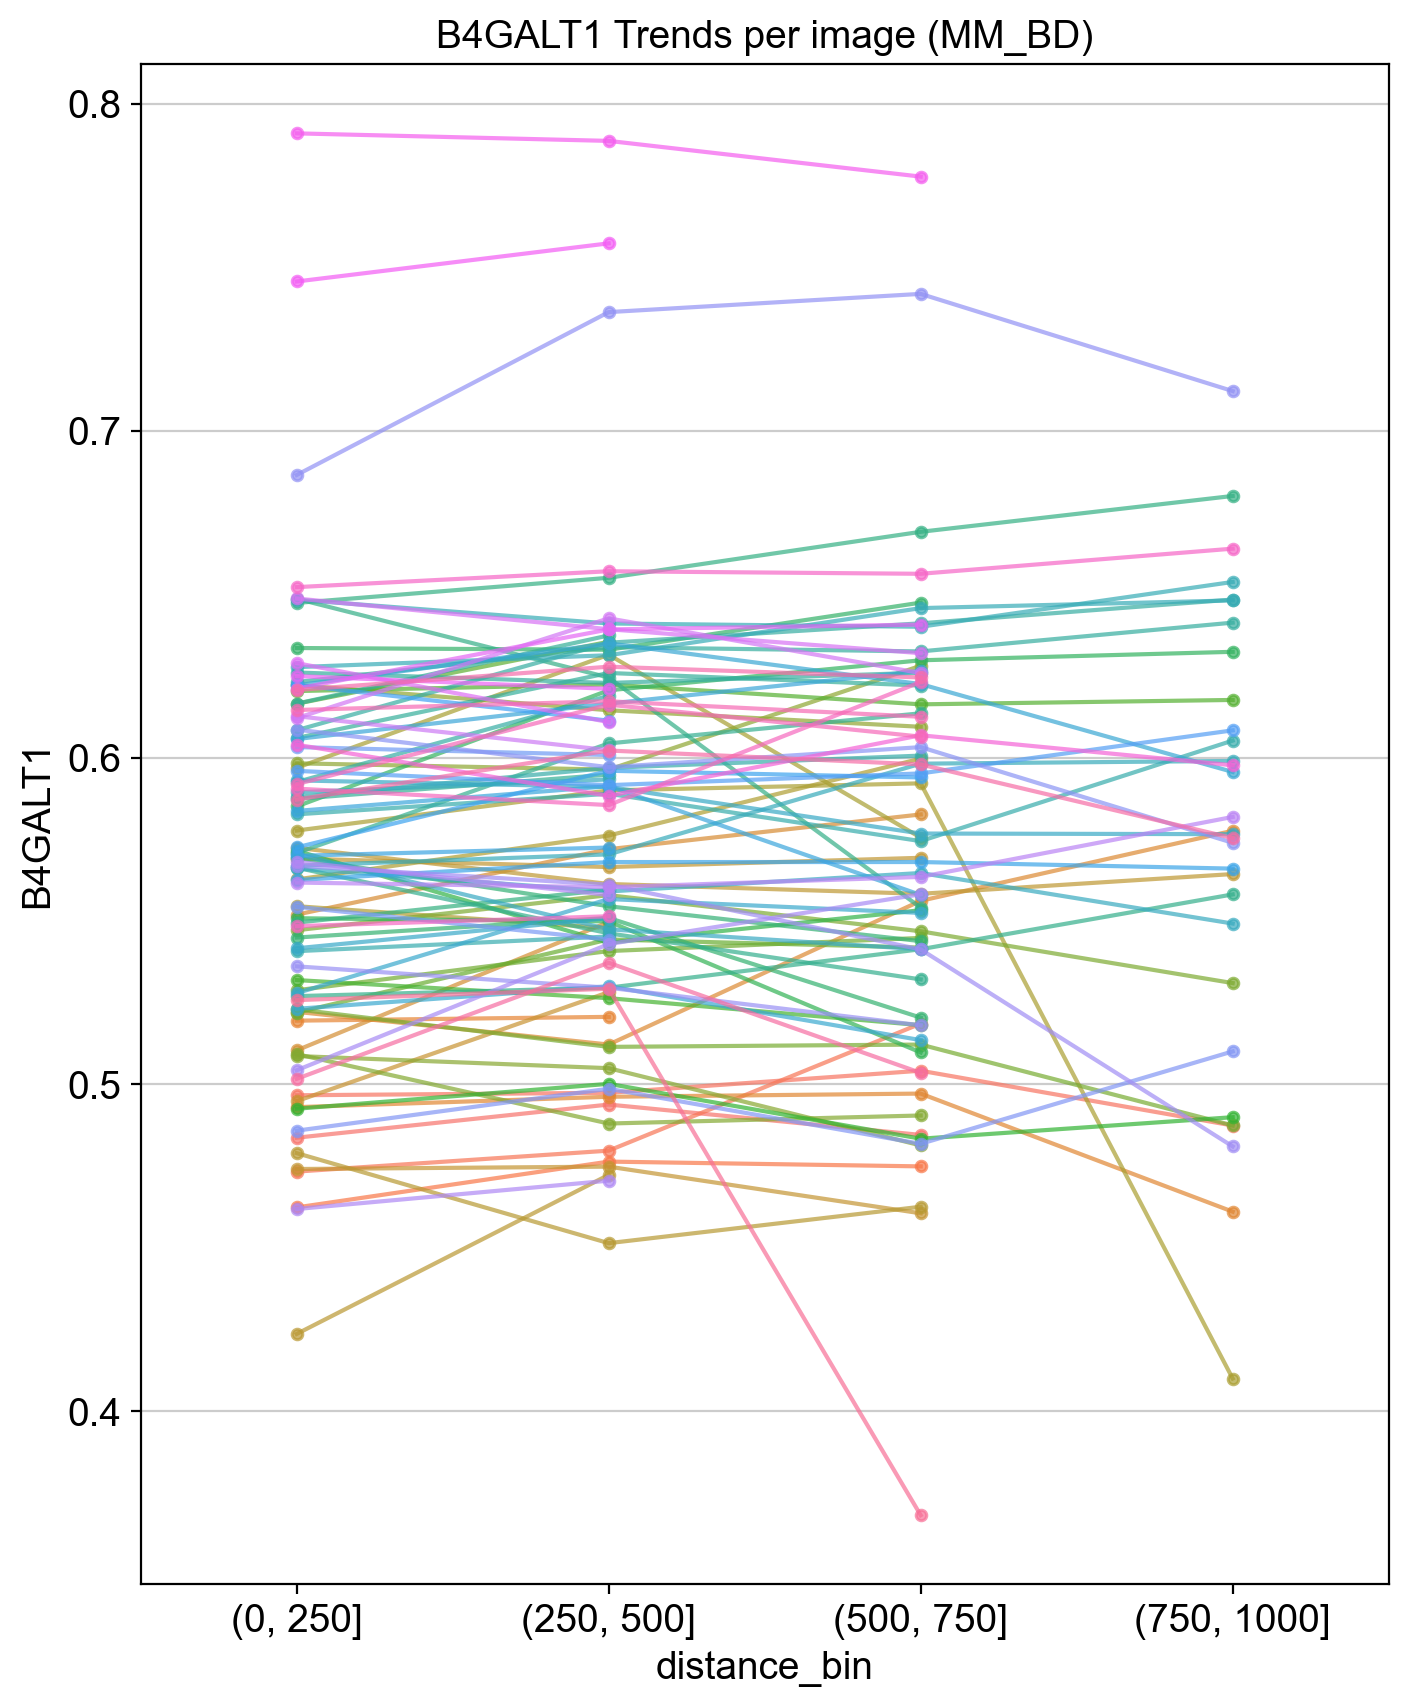

In [31]:
plt.figure(figsize=(8,10))
marker = 'B4GALT1'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == 'MM_BD'], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image (MM_BD)")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_MM_BD.{extension}'))

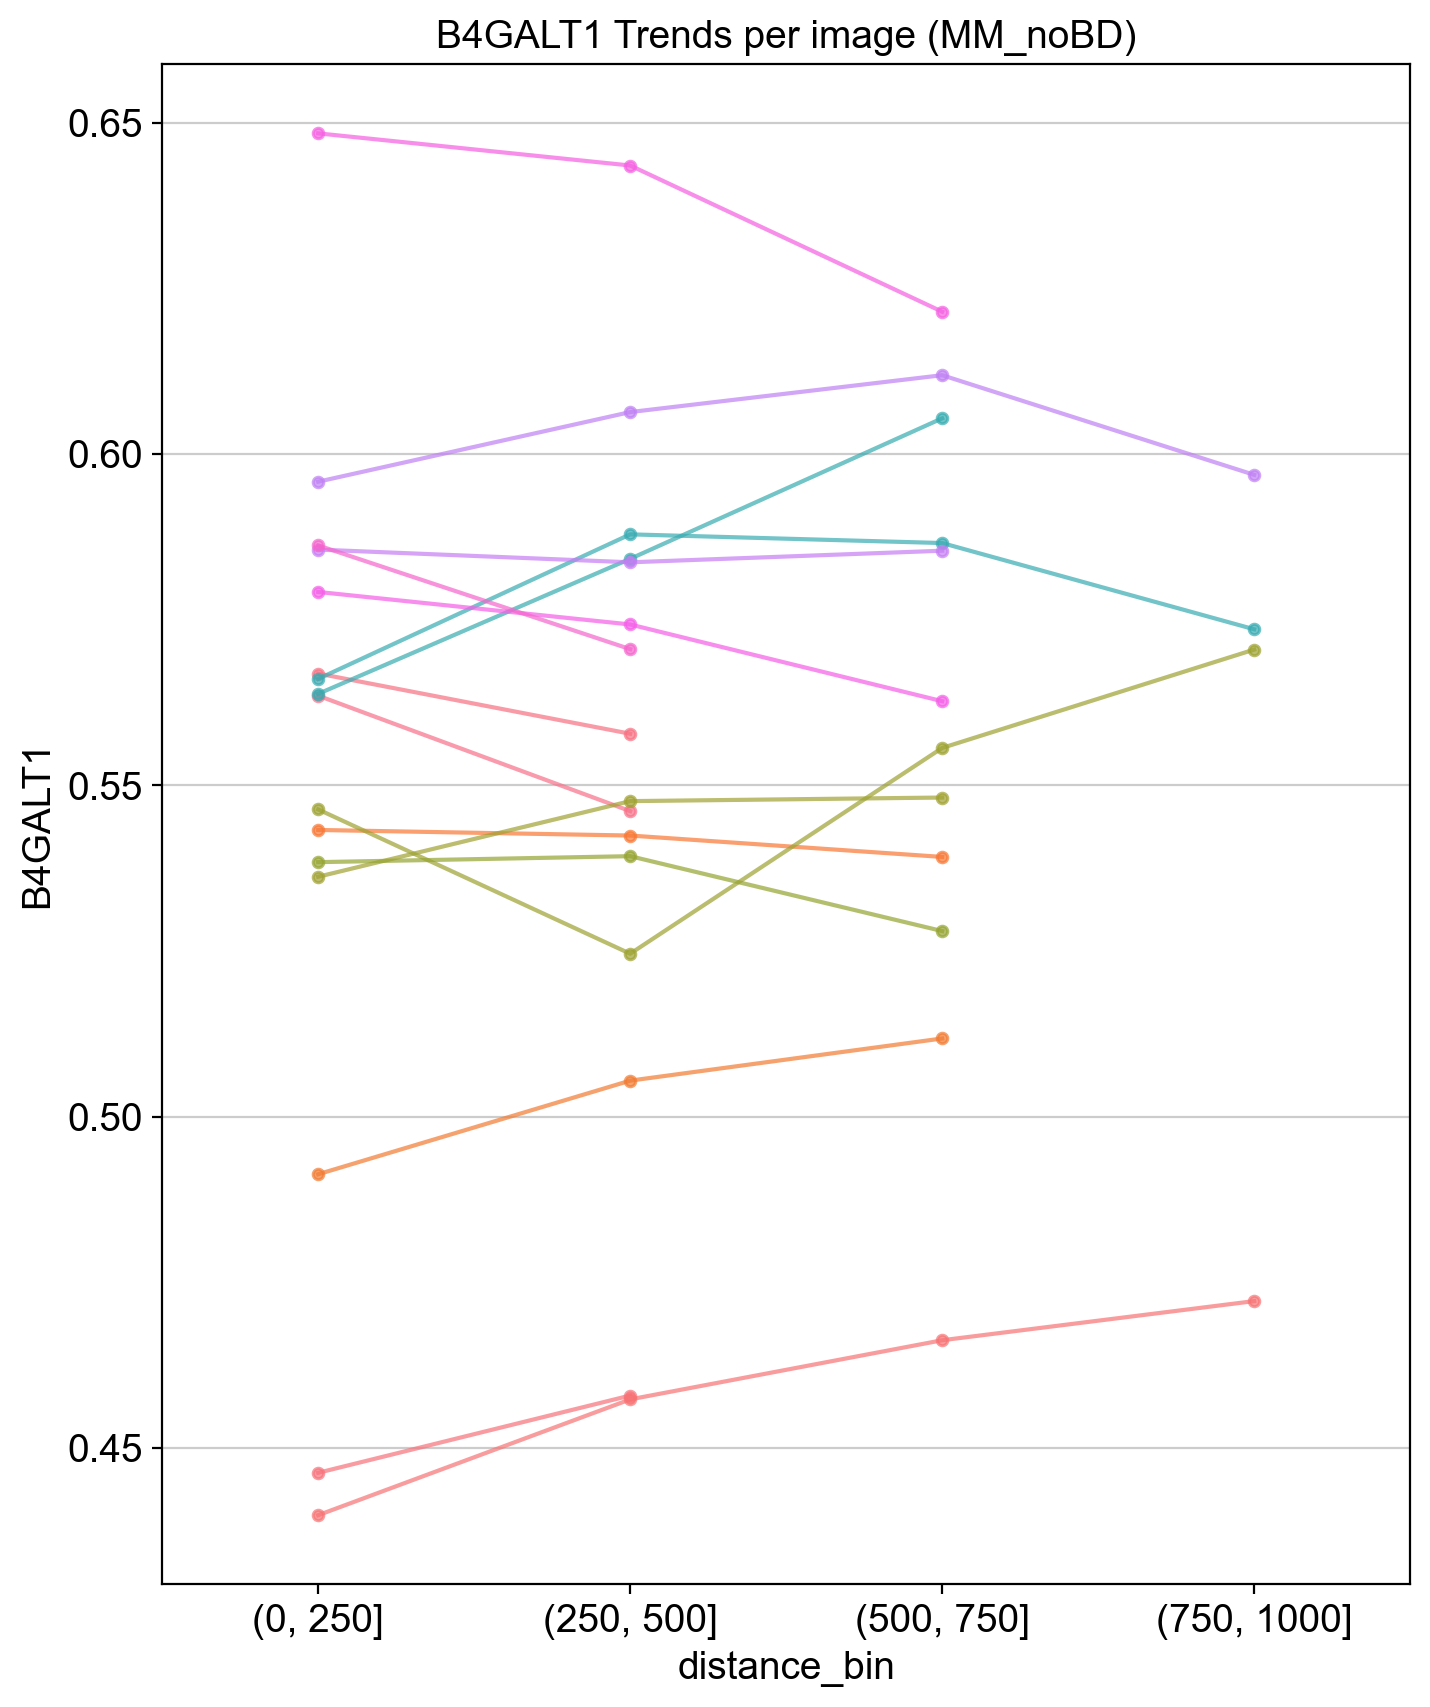

In [32]:
plt.figure(figsize=(8,10))
marker = 'B4GALT1'
group = 'MM_noBD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

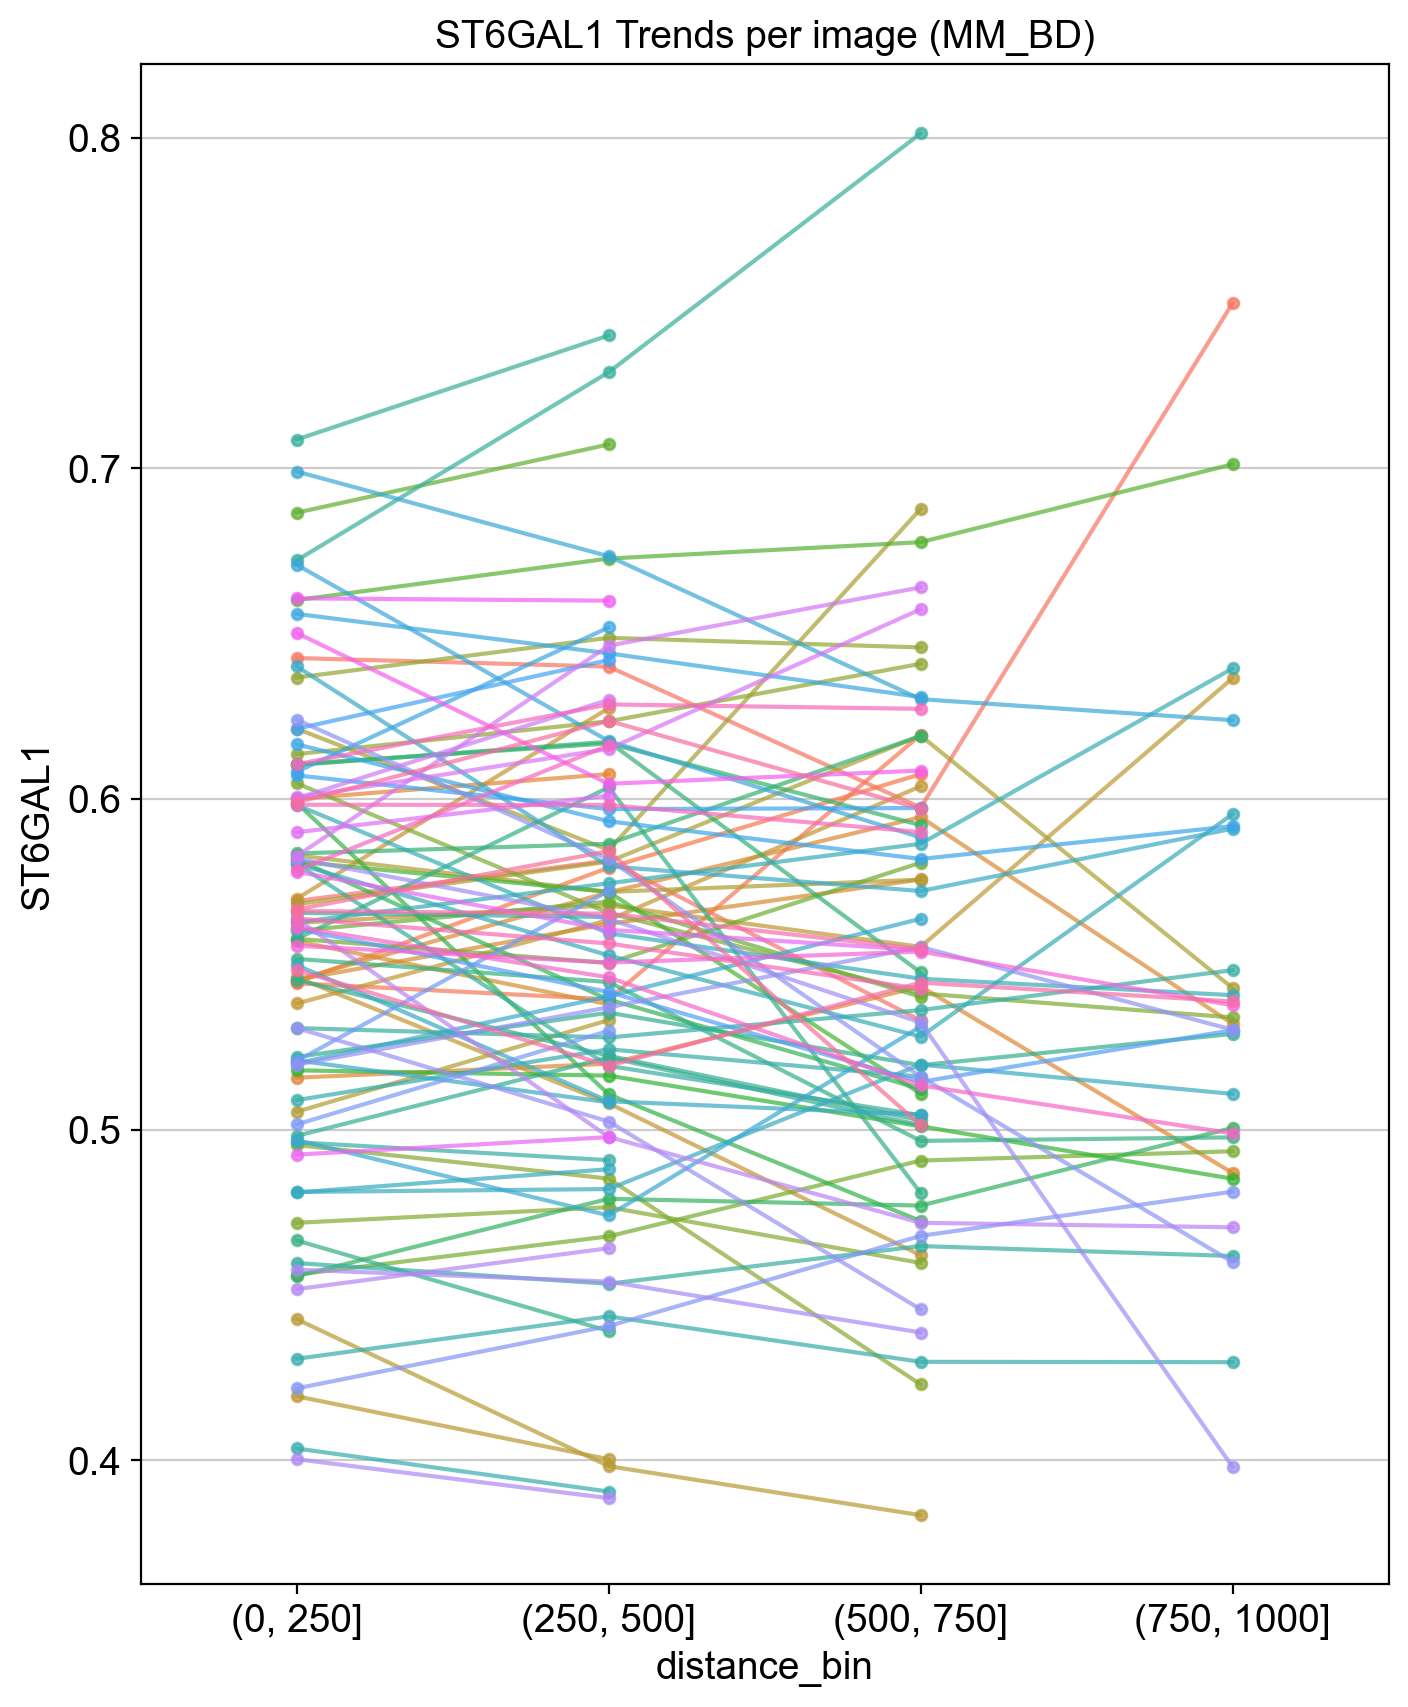

In [33]:
plt.figure(figsize=(8,10))
marker = 'ST6GAL1'
group = 'MM_BD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

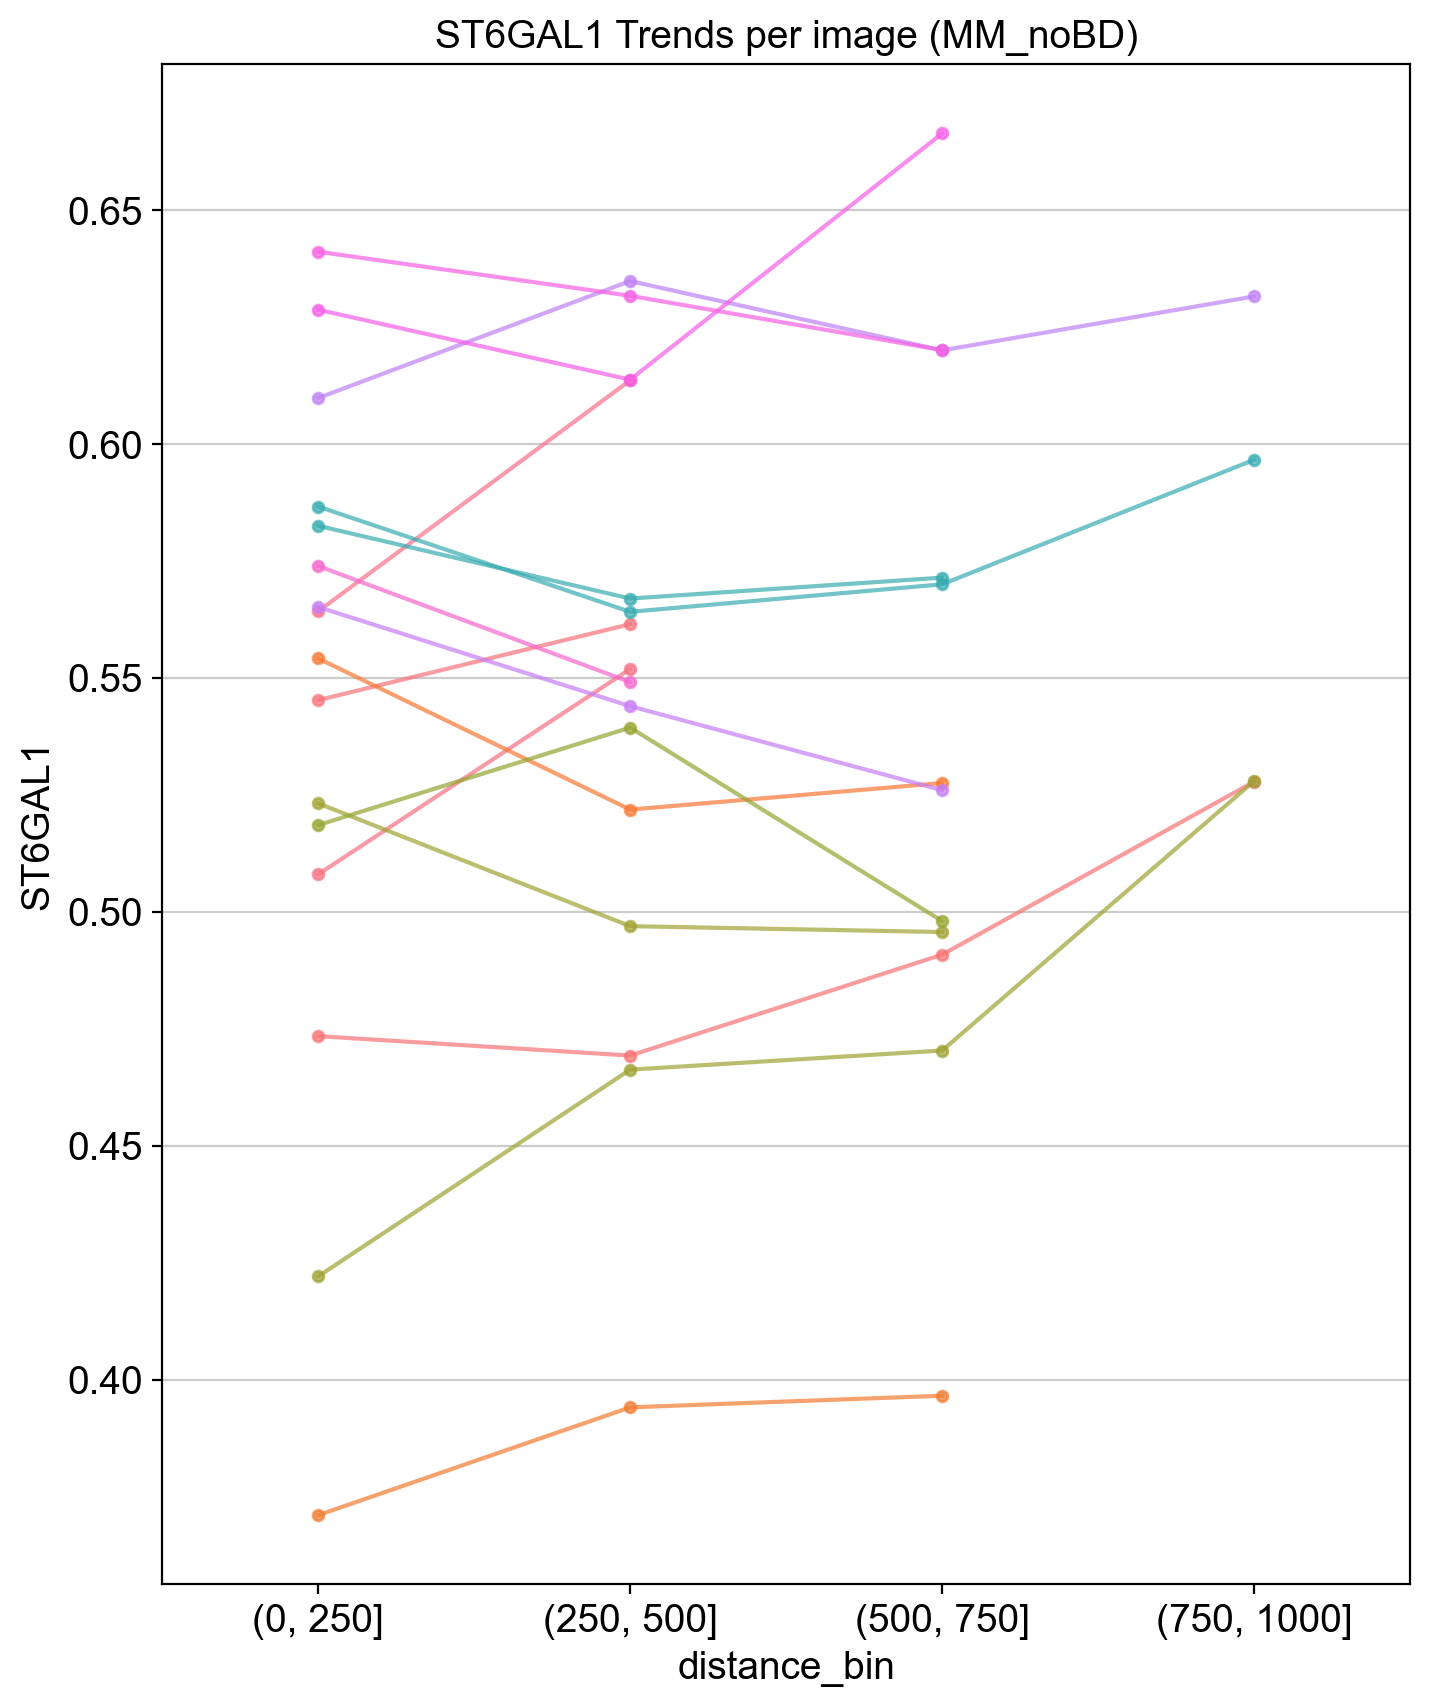

In [34]:
plt.figure(figsize=(8,10))
marker = 'ST6GAL1'
group = 'MM_noBD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

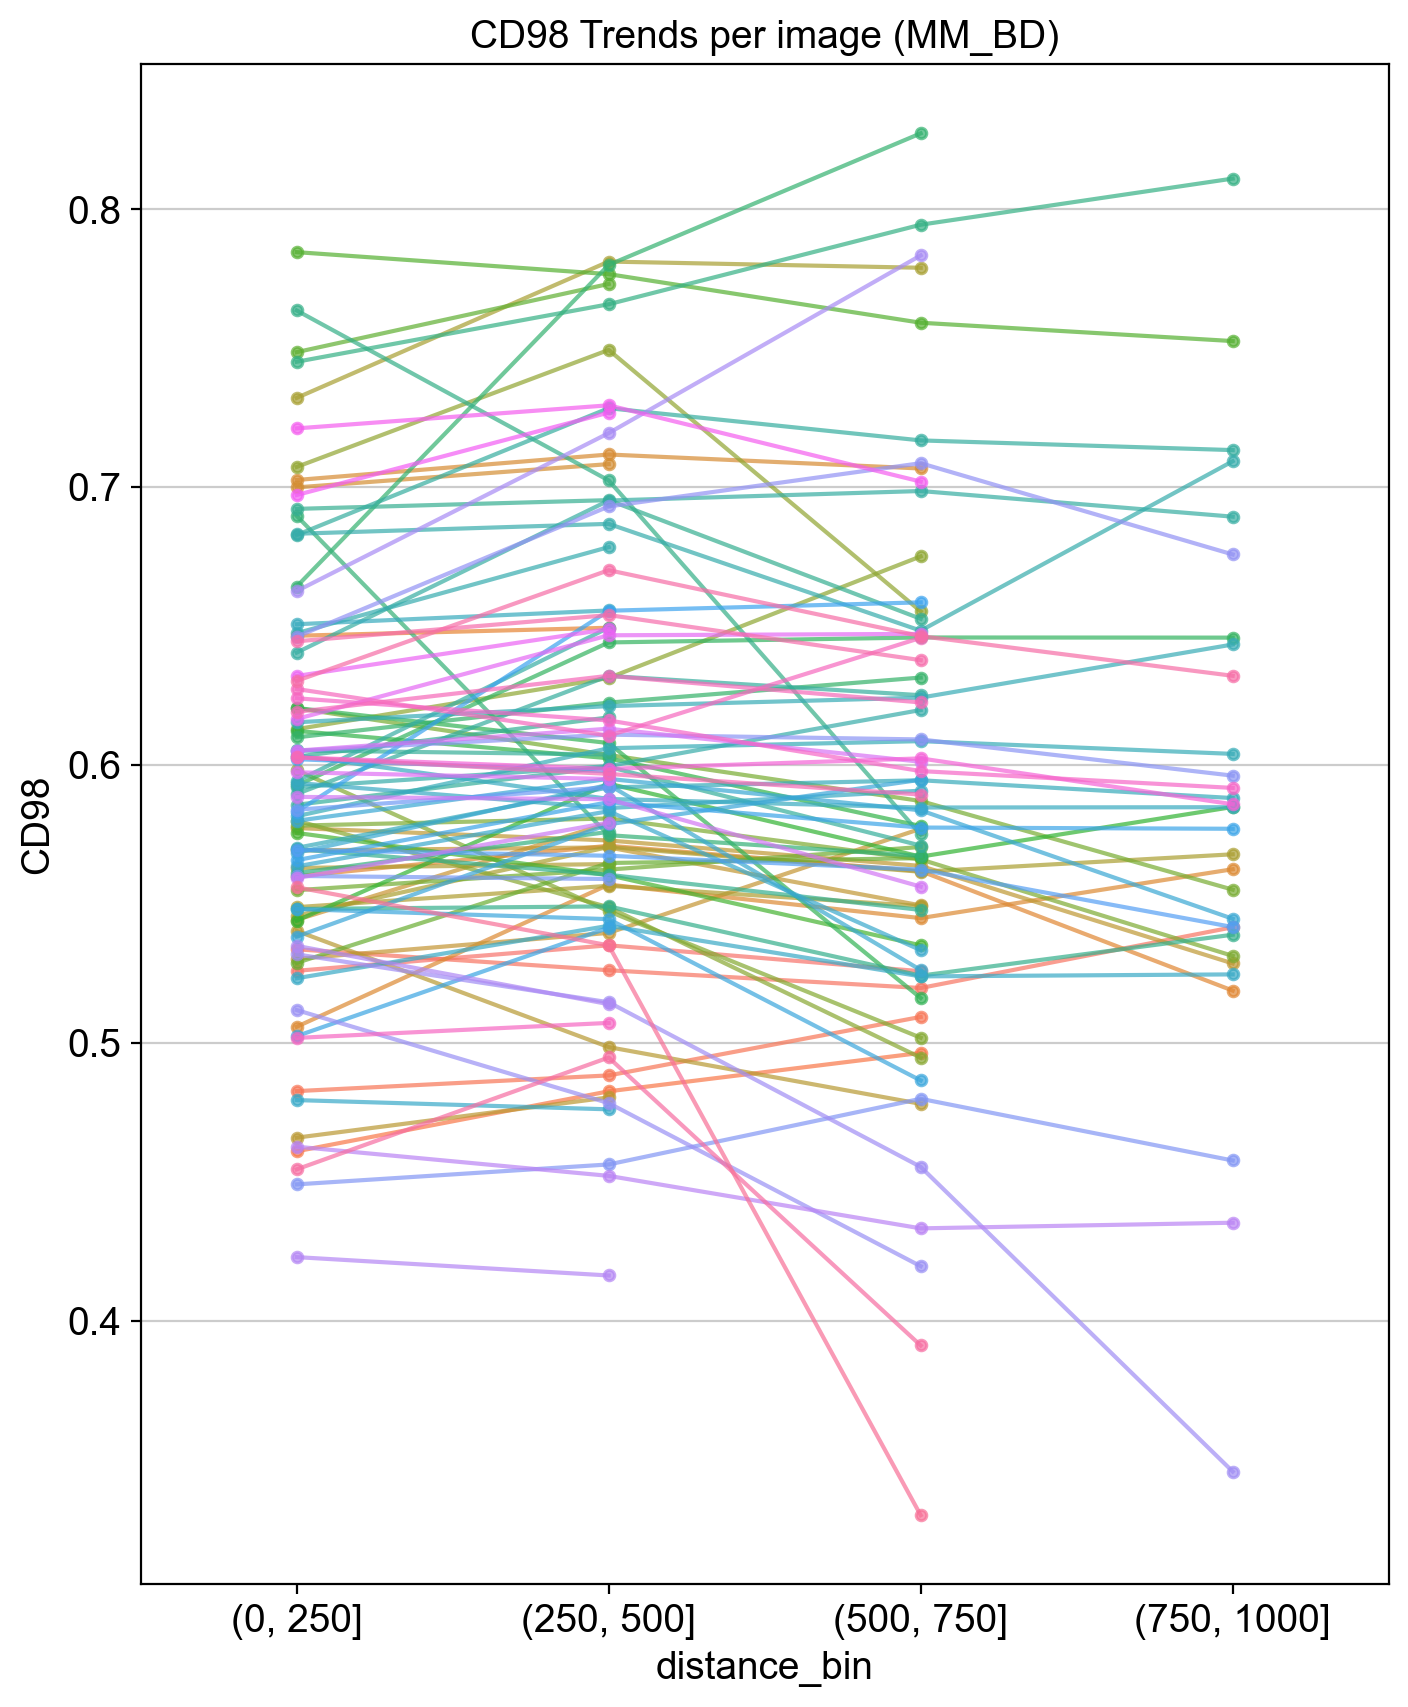

In [35]:
plt.figure(figsize=(8,10))
marker = 'CD98'
group = 'MM_BD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

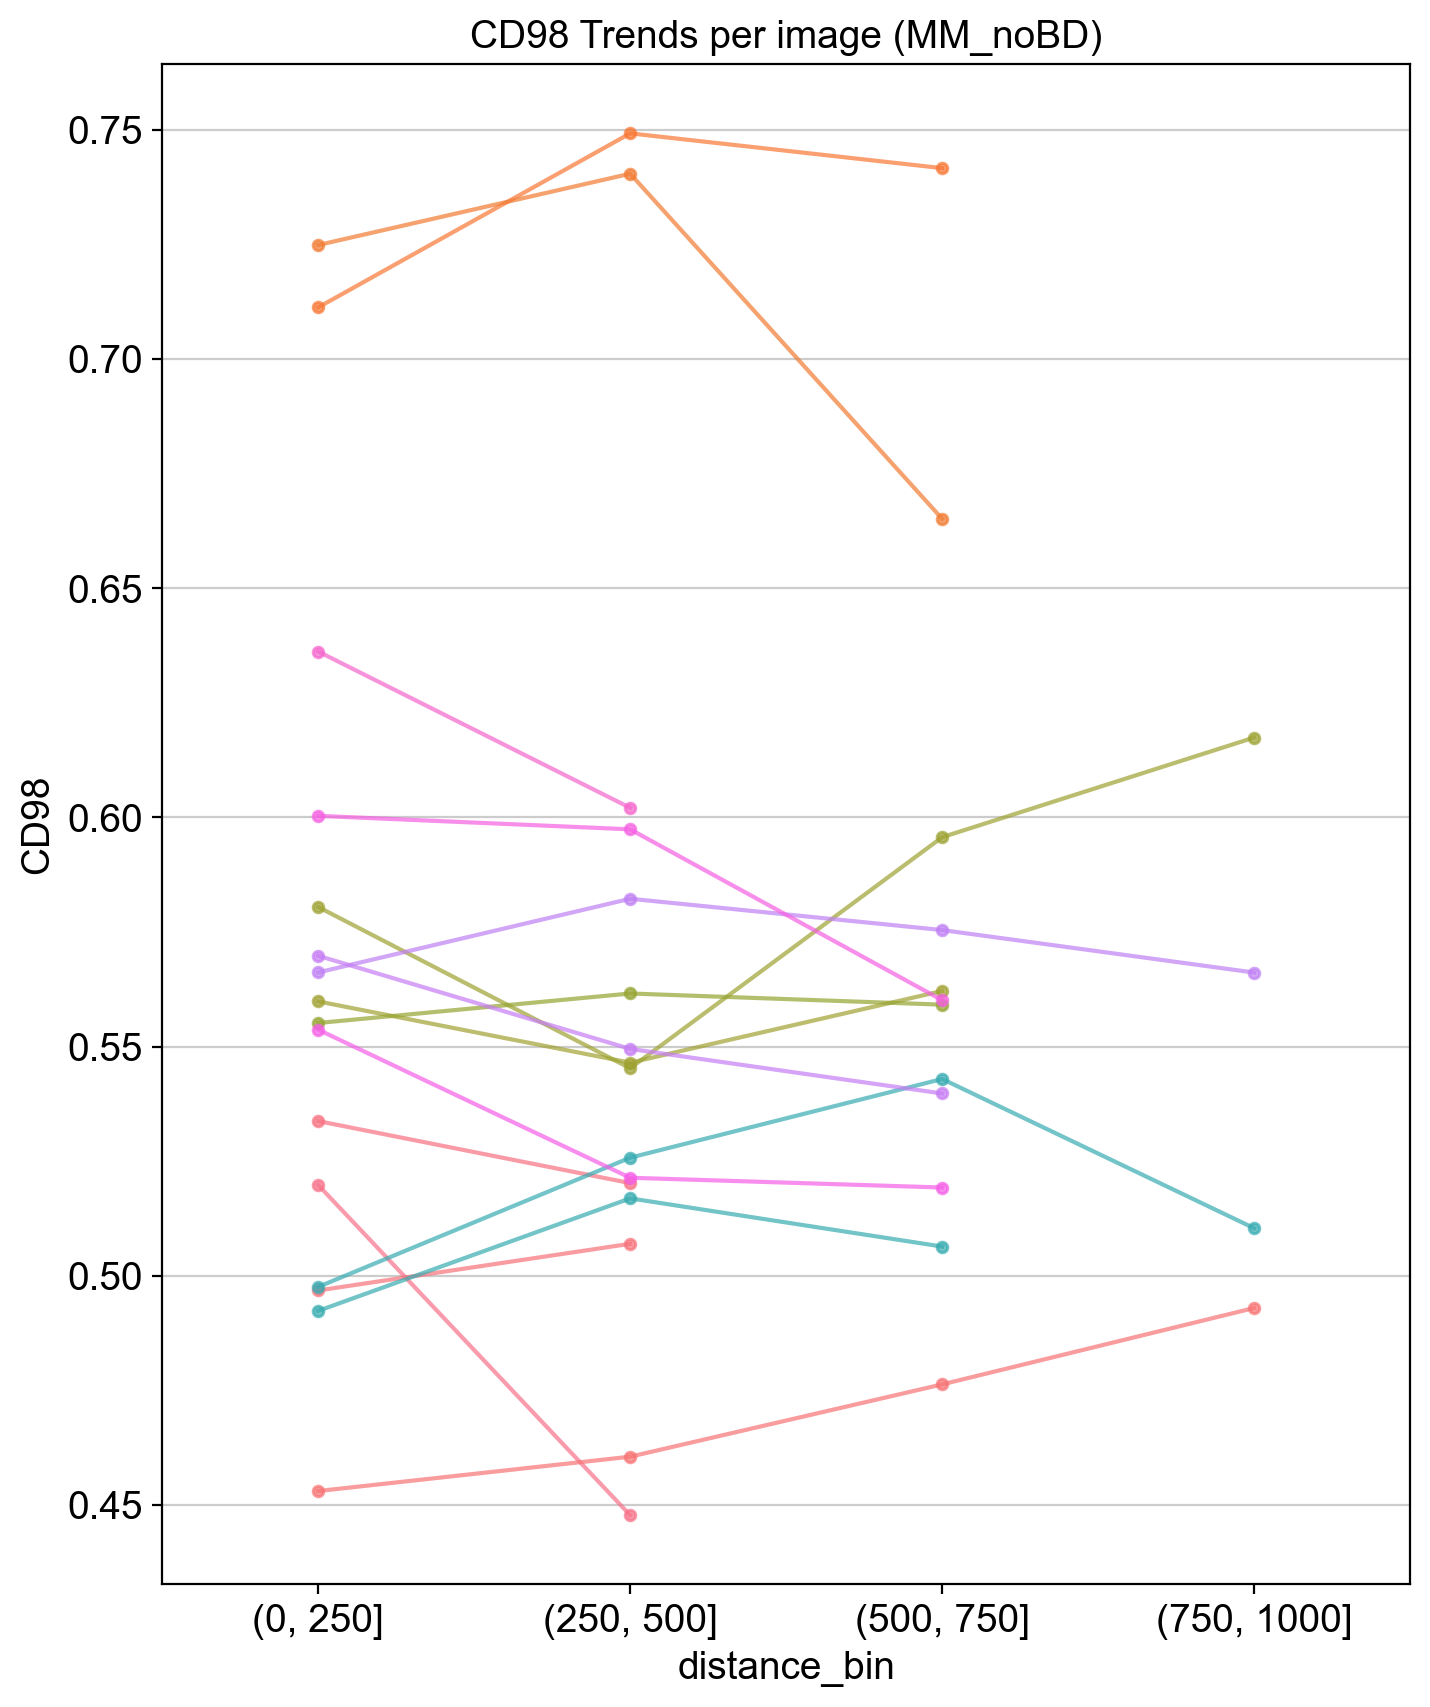

In [36]:
plt.figure(figsize=(8,10))
marker = 'CD98'
group = 'MM_noBD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

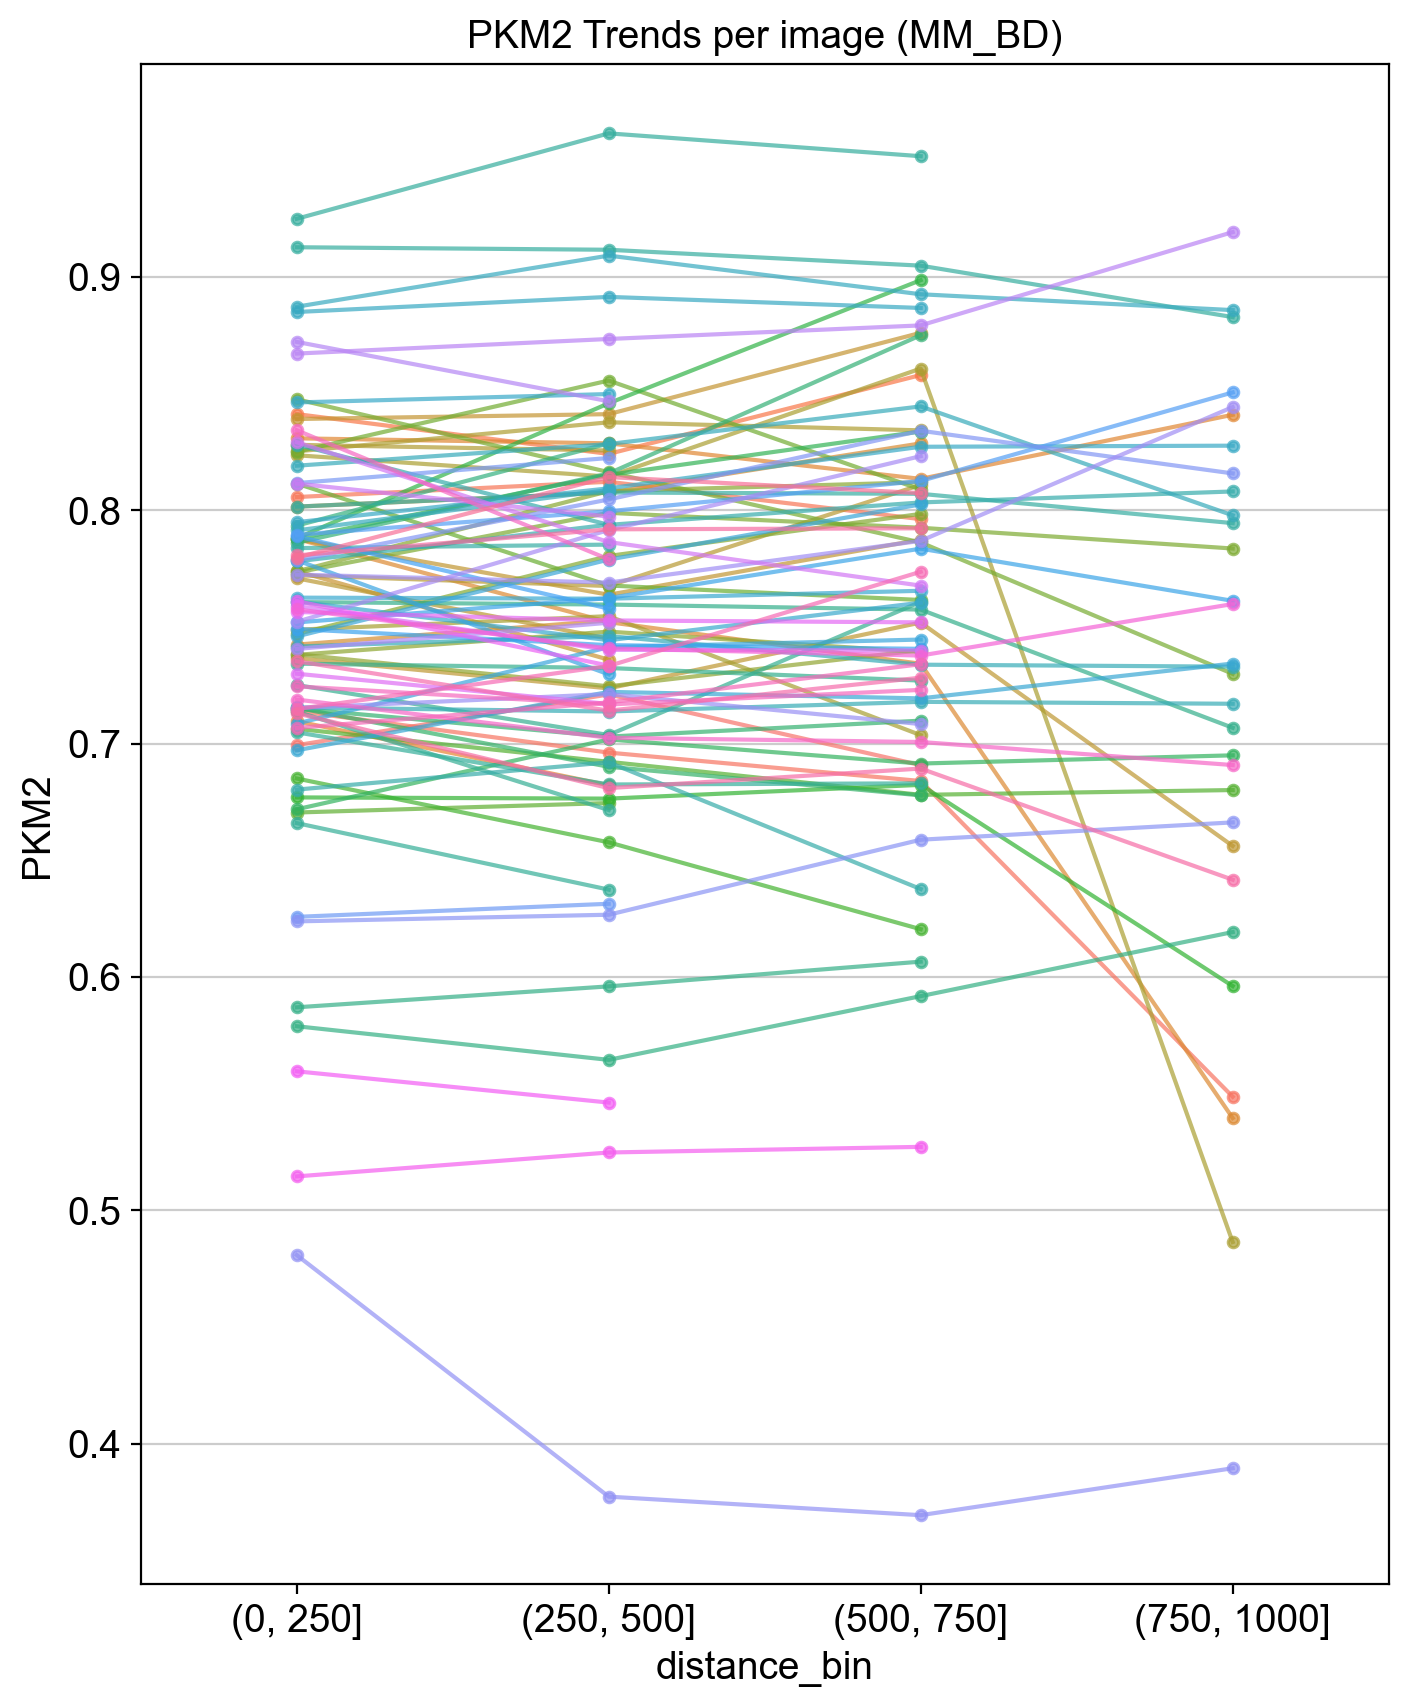

In [37]:
plt.figure(figsize=(8,10))
marker = 'PKM2'
group = 'MM_BD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

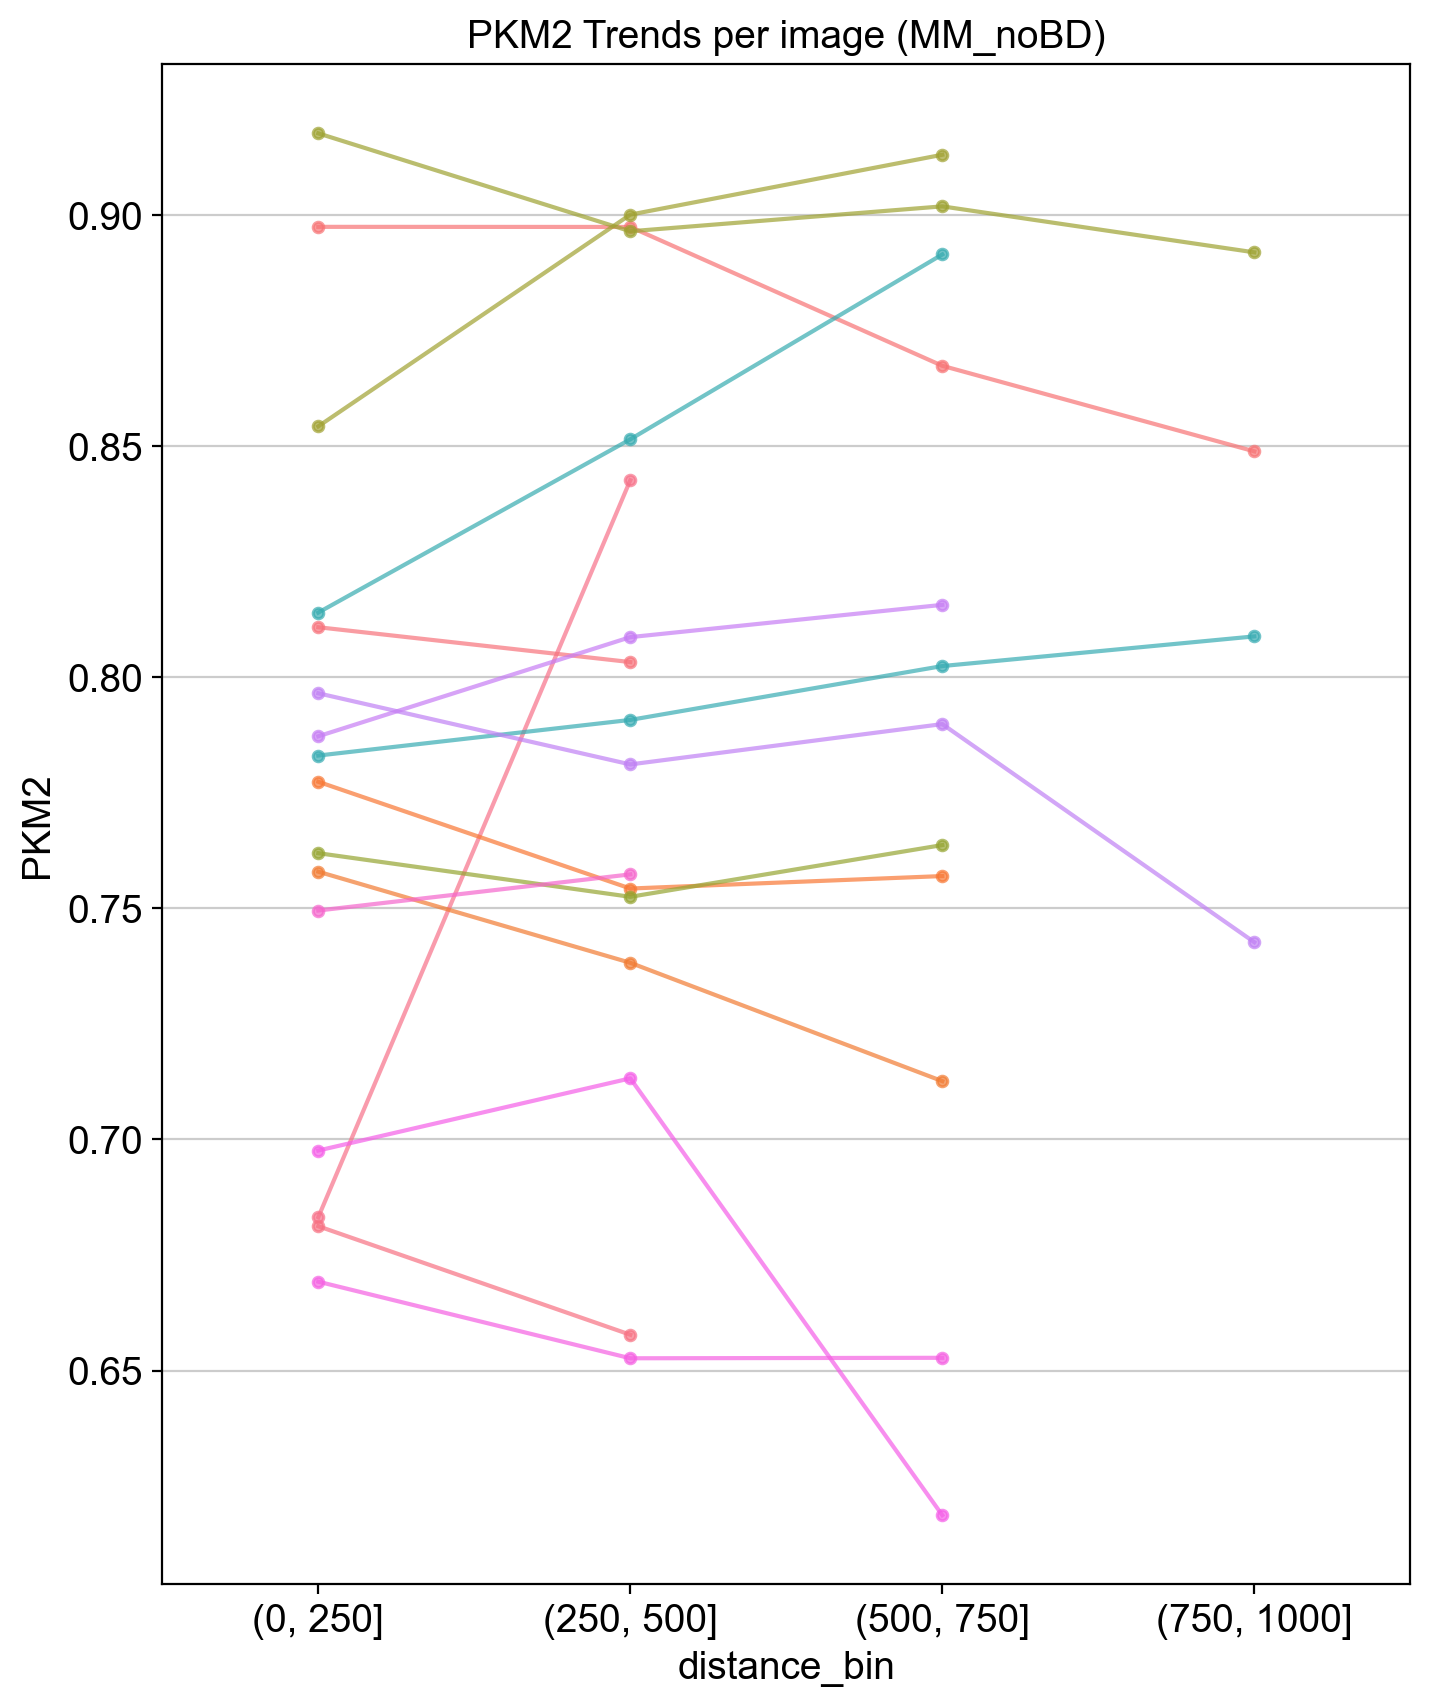

In [38]:
plt.figure(figsize=(8,10))
marker = 'PKM2'
group = 'MM_noBD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

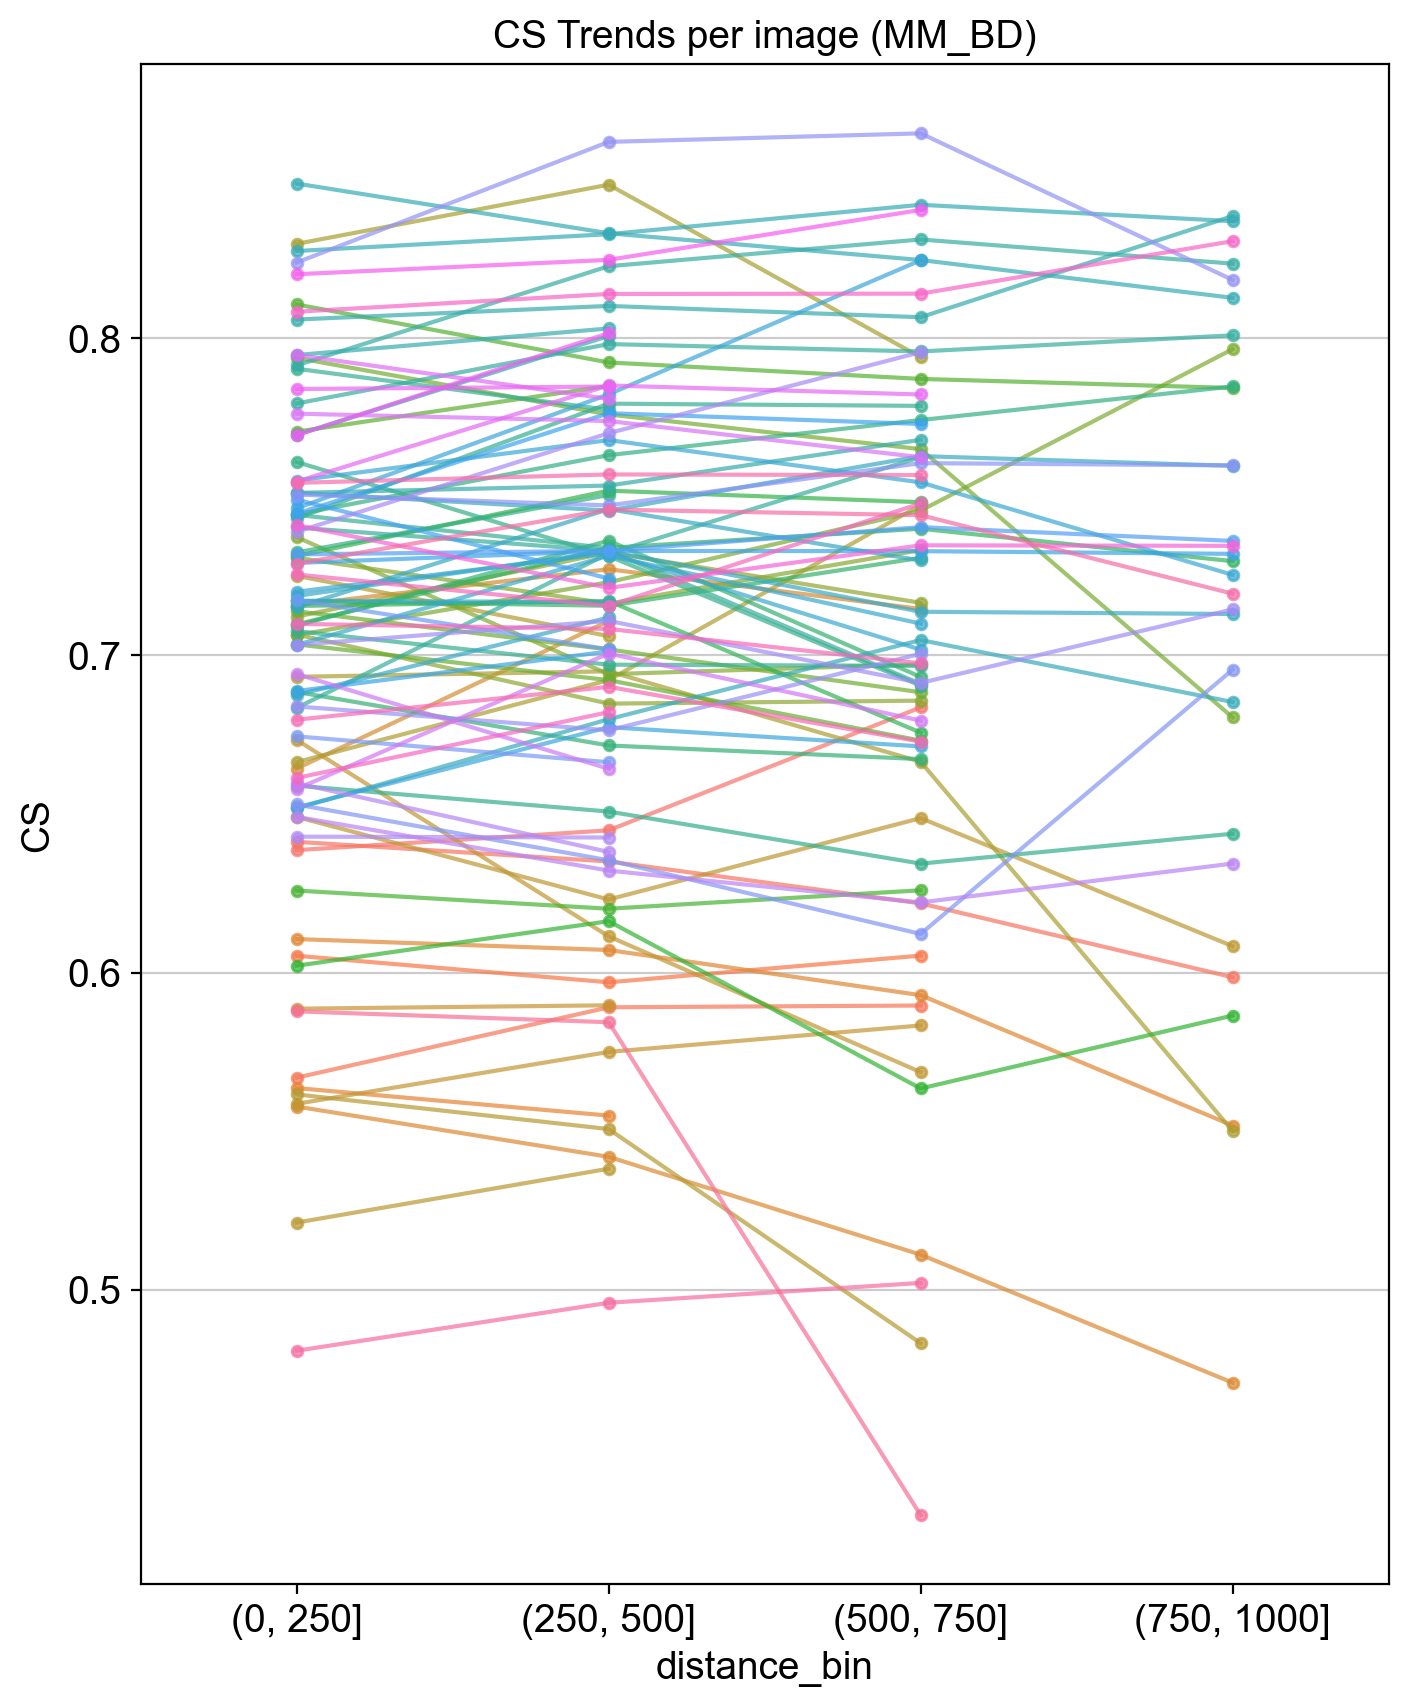

In [39]:
plt.figure(figsize=(8,10))
marker = 'CS'
group = 'MM_BD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

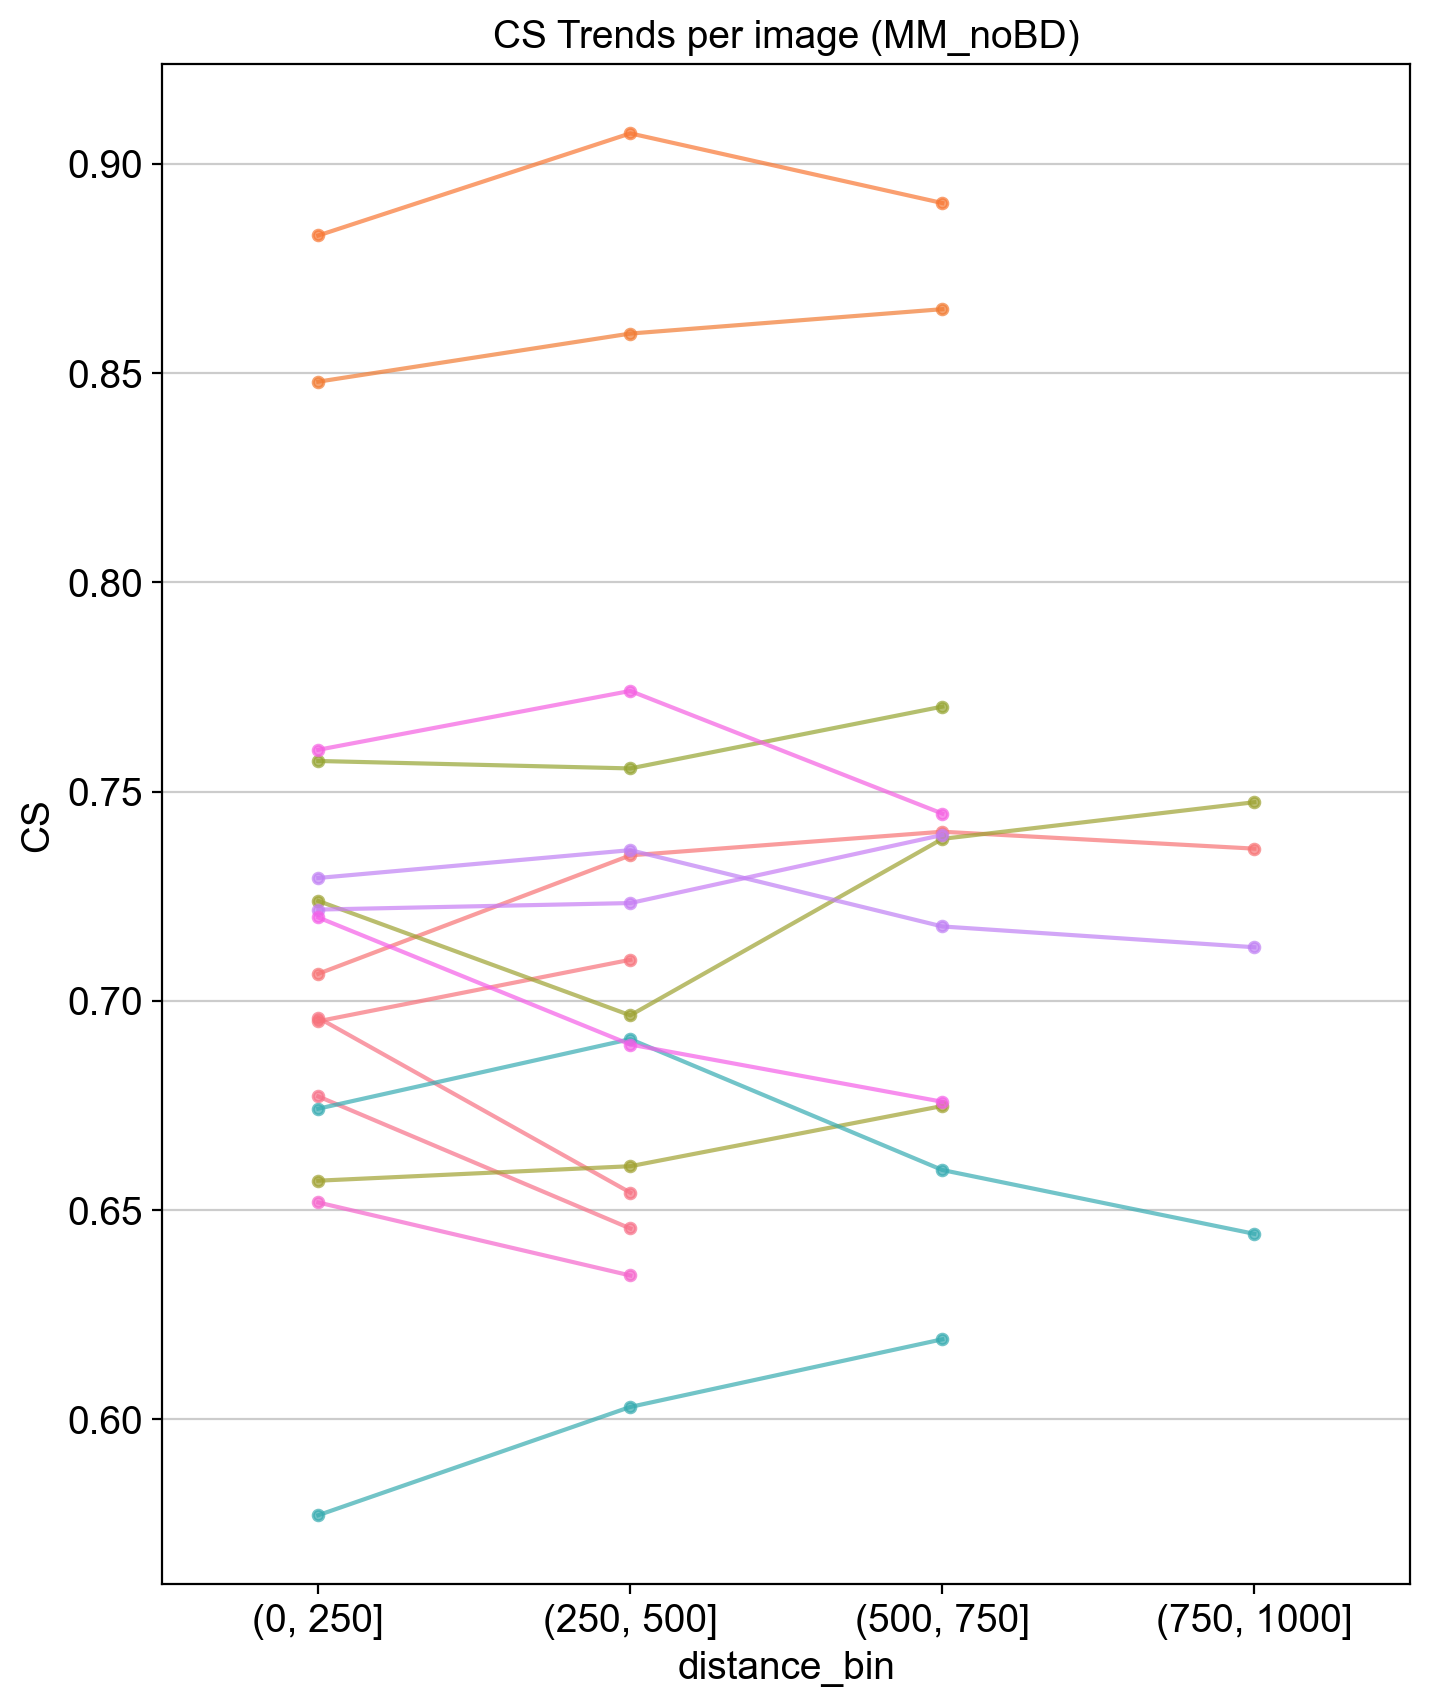

In [40]:
plt.figure(figsize=(8,10))
marker = 'CS'
group = 'MM_noBD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

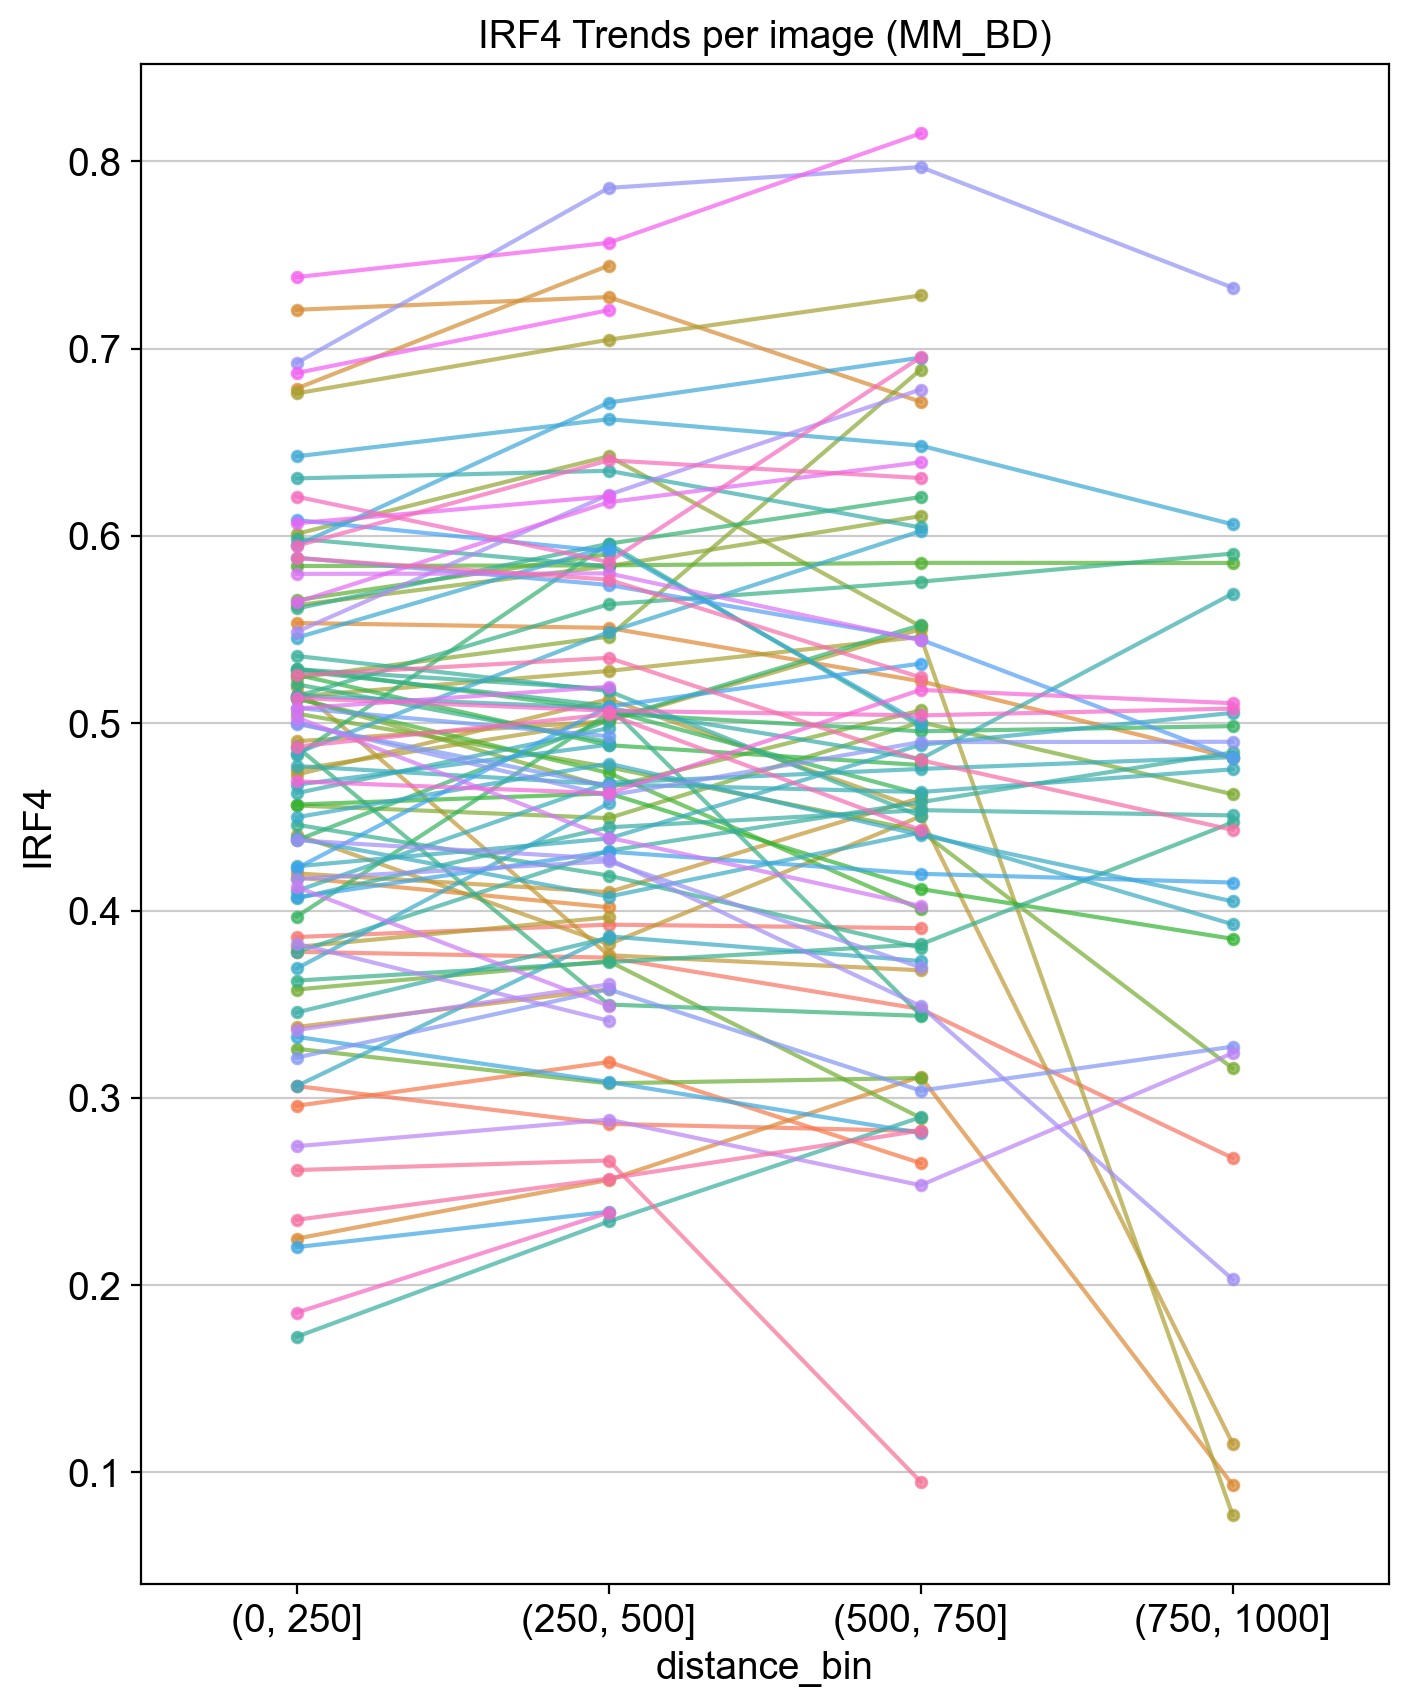

In [41]:
plt.figure(figsize=(8,10))
marker = 'IRF4'
group = 'MM_BD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))

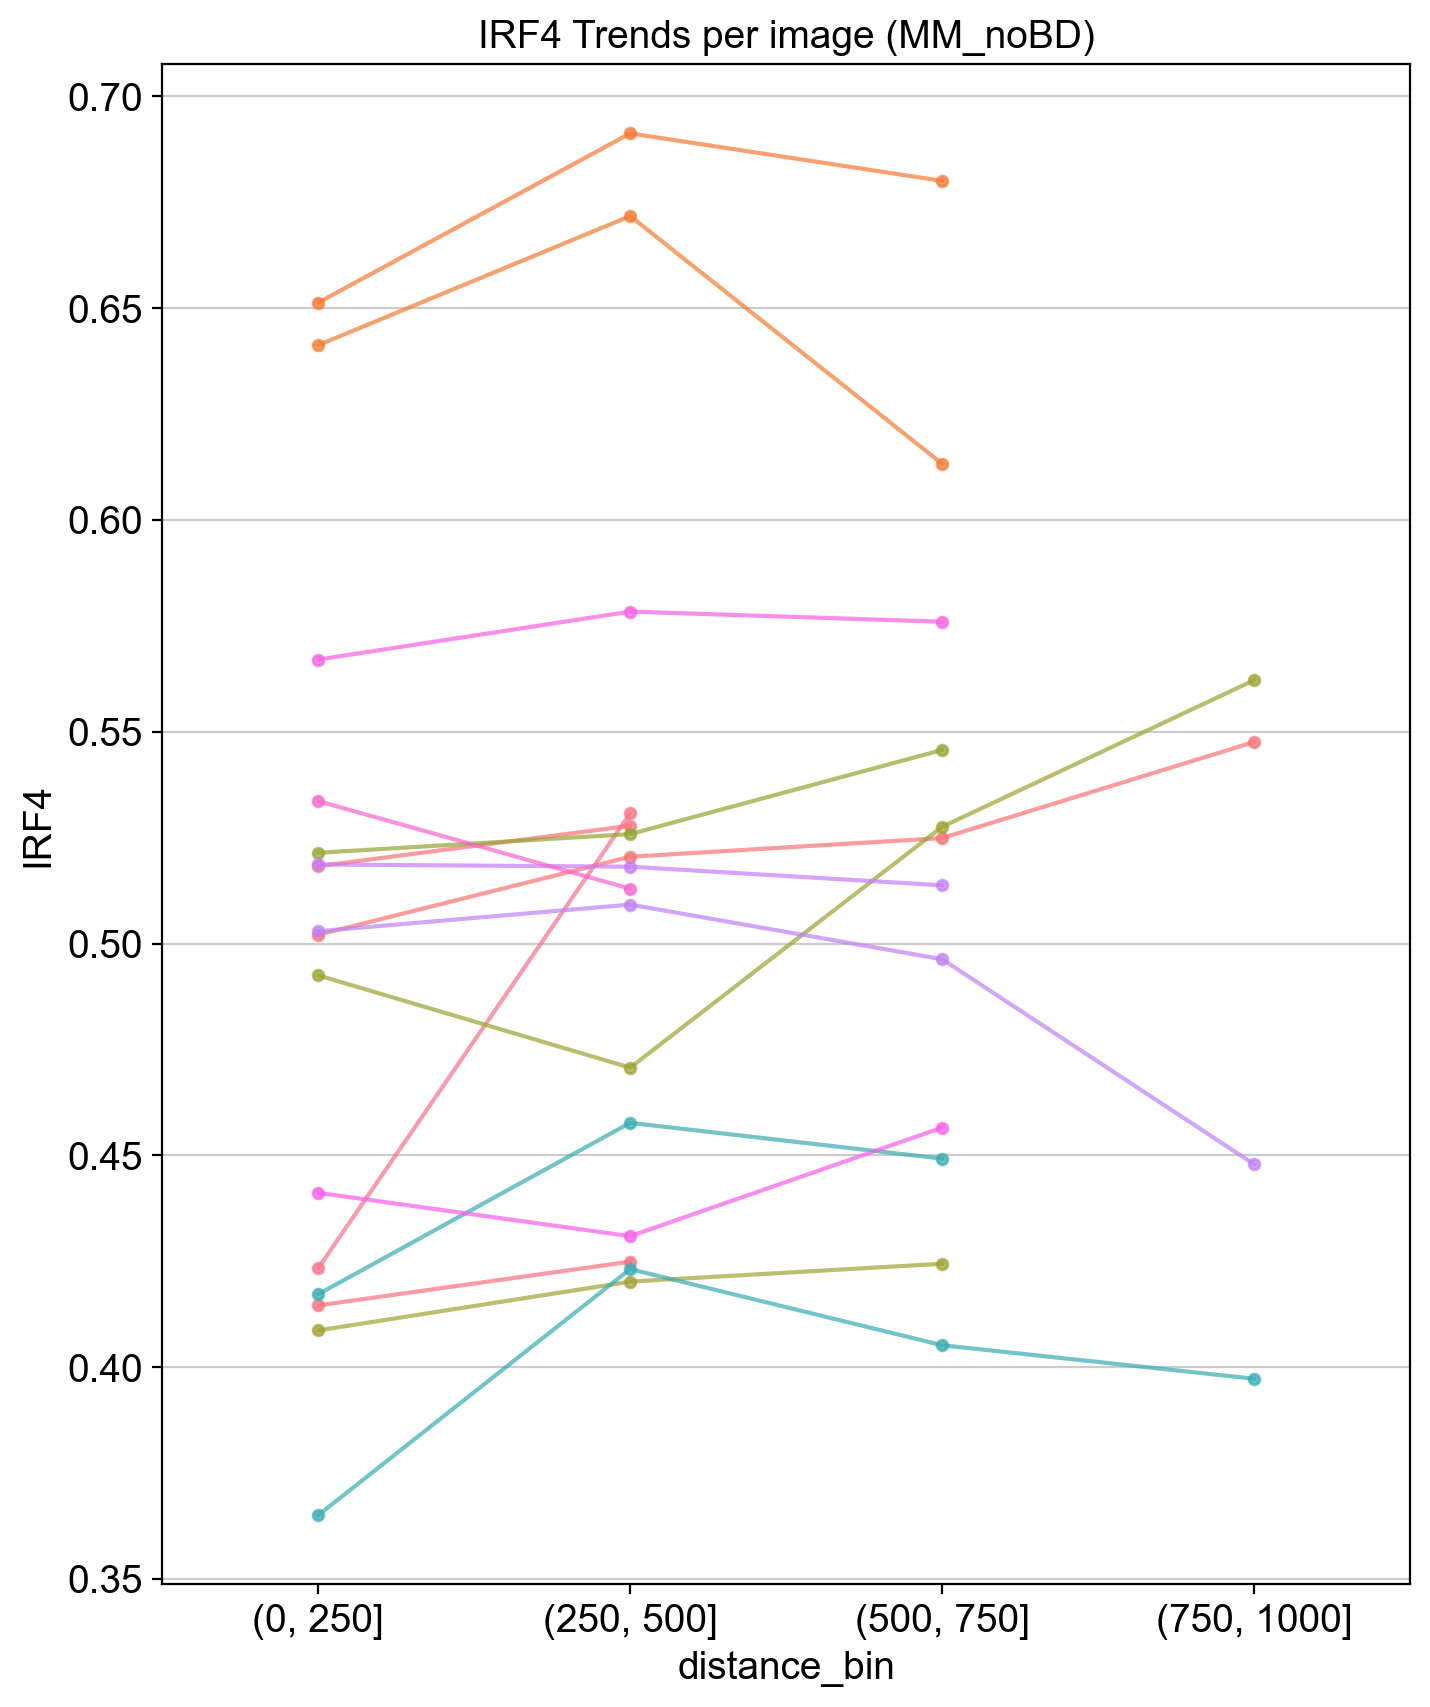

In [42]:
plt.figure(figsize=(8,10))
marker = 'IRF4'
group = 'MM_noBD'
subset_df = df.copy()
subset_df['distance_bin'] = pd.Categorical(
        subset_df['distance_bin'], 
        categories=['(0, 250]', '(250, 500]', '(500, 750]', '(750, 1000]'],
        ordered=True
    )
sns.pointplot(
    data=subset_df[subset_df['disease2'] == group], 
    x='distance_bin', 
    y=marker, 
    hue='image_ID',
    errorbar=None,
    #dodge=True,
    alpha=0.7,
    linewidth=1.5
)
# remove legend if present (plt.legend does not accept show=...)
leg = plt.gca().get_legend()
if leg:
    leg.remove()
plt.title(f"{marker} Trends per image ({group})")
plt.savefig(os.path.join(save_path_supp, f'EDA_bone_distance_{marker}_{group}.{extension}'))